## Introduction

The goal of this project is to apply Kalman Filters (KF) to model the exposure of a trading strategy (in a trading context) or an asset (in an investment context).

In this framework, Realized Volatility (RV) will serve as the primary decision variable. Specifically, we will use Kalman Filters to estimate and smooth the dynamics of realized volatility, and then use this filtered estimate to determine portfolio exposure.

This approach is widely used in quantitative finance. For example, Sheldon Natenberg highlights the Exponentially Weighted Moving Average (EWMA) as one of the simplest and most common methods for forecasting future realized volatility. Similarly, Robert Carver presents volatility-based position sizing and forecasting techniques extensively in his work.

The objective of this experiment is to extend these ideas by replacing traditional smoothing techniques (such as EWMA) with a state-space framework based on Kalman Filters.

The analysis will be conducted using data provided by First Rate Data.

Finally, the experiment will evaluate how the proposed model behaves across different asset classes, highlighting similarities, differences, and robustness of the approach. All this without neglecting the validation process.

In [31]:
#DATA LOADER

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from __future__ import annotations
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Any, Tuple

ROOT_PATH = Path("/mnt/nas/trading_project/data/unprocessed/First Rate Data")

FUTURES_1D_DIR = ROOT_PATH / "futures" / "1day" / "continuous_absolute"
STOCKS_1D_DIR  = ROOT_PATH / "stocks"  / "1day" / "adj_splitdiv"

UNIVERSE_FUT = {
    "crypto": ["BTC"],
    "equity": ["FDAX", "ES"],
    "bond":   ["ZF", "FGBL"],
    "fx":     ["E6", "J7"],
    "vol":    ["VX"],
    "commodity":   ["GC", ],
}

UNIVERSE_STK = ["NVDA", "JPM", "TSLA", "LLY", "XOM"]

FUTURE_SYMBOLS = sorted({s for v in UNIVERSE_FUT.values() for s in v})
STOCK_TICKERS  = UNIVERSE_STK

df_futures_daily = {}

for sym in FUTURE_SYMBOLS:
    file_path = FUTURES_1D_DIR / f"{sym}_full_1day_continuous_absolute_adjusted.txt"

    df = pd.read_csv(
        file_path,
        header=None,
        sep=","
    )

    df.columns = ["datetime", "open", "high", "low", "close", "volume", "open interest"]

    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"]).set_index("datetime").sort_index()

    df_futures_daily[sym] = df


df_stocks_daily = {}

for ticker in STOCK_TICKERS:
    matches = list(STOCKS_1D_DIR.rglob(f"{ticker}*"))
    if len(matches) == 0:
        raise FileNotFoundError(f"Stock file non trovato per {ticker}")

    file_path = matches[0]

    df = pd.read_csv(
        file_path,
        header=None,
        sep=","
    )

    df.columns = ["datetime", "open", "high", "low", "close", "volume"]

    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"]).set_index("datetime").sort_index()

    df_stocks_daily[ticker] = df


df_instruments_1d = {f"FUT_{k}": v for k, v in df_futures_daily.items()}
df_instruments_1d.update({f"STK_{k}": v for k, v in df_stocks_daily.items()})

In [33]:

#BASIC CLEANING FUNCTIONS

def sanitize_index(df: pd.DataFrame) -> pd.DataFrame:
    """Drop NaT index, sort, drop duplicate timestamps (keep last)."""
    out = df.copy()
    if not isinstance(out.index, pd.DatetimeIndex):
        raise TypeError("Index is not a DatetimeIndex")
    out = out[~out.index.isna()].sort_index()
    if out.index.has_duplicates:
        out = out[~out.index.duplicated(keep="last")]
    return out

def normalize_to_utc(df: pd.DataFrame) -> pd.DataFrame:
    """Make index timezone-aware in UTC (assume naive timestamps are UTC)."""
    out = df.copy()
    if out.index.tz is None:
        out.index = out.index.tz_localize("UTC")
    else:
        out.index = out.index.tz_convert("UTC")
    return out

def enforce_grid(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    """
    Floor timestamps to a regular grid (useful if data has off-grid stamps).
    Example freq: "5min", "1h".
    """
    out = df.copy()
    out.index = out.index.floor(freq)
    out = out[~out.index.duplicated(keep="last")].sort_index()
    return out

def coerce_ohlcv_numeric(df: pd.DataFrame, cols=("open","high","low","close","volume")) -> pd.DataFrame:
    """Coerce typical OHLCV columns to numeric (non-convertible -> NaN)."""
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def prep_asset_simple(
    df: pd.DataFrame,
    tf: str,
    enforce_freq: str | None = None,   
    cols=("open","high","low","close","volume")
) -> tuple[pd.DataFrame, dict]:

    x = sanitize_index(df)
    x = normalize_to_utc(x)

    if enforce_freq is not None:
        x = enforce_grid(x, enforce_freq)

    x = coerce_ohlcv_numeric(x, cols=cols)

    rep = {
        "tf": tf,
        "n_rows": len(x),
        "start": x.index.min(),
        "end": x.index.max(),
        "tz": str(x.index.tz),

        "n_cols": x.shape[1],
        "cols": list(x.columns),

        "index_has_dups": bool(x.index.has_duplicates),
        "index_is_monotonic": bool(x.index.is_monotonic_increasing),

        "open_nan_pct":  float(x["open"].isna().mean())  if "open" in x.columns else np.nan,
        "high_nan_pct":  float(x["high"].isna().mean())  if "high" in x.columns else np.nan,
        "low_nan_pct":   float(x["low"].isna().mean())   if "low" in x.columns else np.nan,
        "close_nan_pct": float(x["close"].isna().mean()) if "close" in x.columns else np.nan,
        "vol_nan_pct":   float(x["volume"].isna().mean()) if "volume" in x.columns else np.nan,

        "bad_ohlc_rows": int((x["high"] < x["low"]).sum()) if all(c in x.columns for c in ["high","low"]) else np.nan,
    }

    return x, rep

def prep_universe_simple(
    d: dict,
    tf: str,
    enforce_freq: str | None = None
) -> tuple[dict, pd.DataFrame]:
    
    out = {}
    reps = []
    for k, df in d.items():
        df_p, rep = prep_asset_simple(df, tf=tf, enforce_freq=enforce_freq)
        out[k] = df_p
        rep["instrument"] = k
        reps.append(rep)

    registry = pd.DataFrame(reps).sort_values(["instrument"]).reset_index(drop=True)
    return out, registry

df_1d_clean, reg_1d = prep_universe_simple(df_instruments_1d, tf="1d", enforce_freq=None)

In [34]:
#CREATE SIMPLE DAILY RETURNS 

def add_simple_returns(universe, price_col="close", ret_col="return"):
    out = {}

    for name, df in universe.items():
        x = df.copy()

        r = x[price_col].pct_change()
        r = r.replace([np.inf, -np.inf], np.nan)

        x[ret_col] = r
        out[name] = x

    return out


df_1d_clean_ret = add_simple_returns(df_1d_clean)

print("Simple returns added.")

df_instruments_1d = df_1d_clean_ret

Simple returns added.


In the next cell I'm going to build the EWMA function for the daily timeframe. 

The half-life parameter is not choosen randomly, but is the parameter used by Rober Carver in his books. 

In [35]:
# CONTRACT MULTIPLIERS & CURRENCY

CONTRACT_MULT = {
    "FUT_ES": 50.0,
    "FUT_GC": 100.0,
    "FUT_VX": 1000.0,
    "FUT_ZF": 1000.0,
    "FUT_FDAX": 25.0,
    "FUT_FGBL": 1000.0,
    "FUT_E6": 125000.0,
    "FUT_J7": 12500000.0,
    "FUT_BTC": 5.0,
    "STK_NVDA": 1.0,
    "STK_JPM": 1.0,
    "STK_TSLA": 1.0,
    "STK_LLY": 1.0,
    "STK_XOM": 1.0,
}

INSTR_CCY = {
    "FUT_ES": "USD",
    "FUT_CL": "USD",
    "FUT_GC": "USD",
    "FUT_VX": "USD",
    "FUT_ZF": "USD",
    "FUT_BTC": "USD",
    "FUT_E6": "USD",
    "FUT_J7": "USD",
    "FUT_FDAX": "EUR",
    "FUT_FGBL": "EUR",
    "STK_NVDA": "USD",
    "STK_JPM": "USD",
    "STK_TSLA": "USD",
    "STK_LLY": "USD",
    "STK_XOM": "USD",
}

### EWMA - Building the Benchmark 

The volatility is estimated through a weighted exponential variance:
$$
\sigma_t = \sqrt{ \lambda \, \sigma_{t-1}^2 + (1 - \lambda)\, r_t^2 }
$$
Where $\sigma_t$ is the volatility estimated at time $t$, $r_t^2$ is the squared returns at time $t$ and $\lambda$ is the decay parameter.
Parameterization happens when we define $\lambda$ through the half-life: 
$$  
\lambda = e^{-\frac{\ln(2)}{h}}  
$$
Where $h$ is the half-life (number of periods for halving the weight).
In this framework I used $36$ as fixed half-life. This is the same parameter used by Robert Carver in different books. 
Note that having a fixed number is a sensible choice when we are looking for something that should not be perfect, but: smooth and robust.


In [36]:
#BUILDING EWMA 1 
def ewma_sigma_from_returns(ret: pd.Series, half_life: int) -> pd.Series:
  
    x = ret.astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) < 2:
        return pd.Series(index=ret.index, dtype=float)

    lam = np.exp(-np.log(2) / half_life)

    var = x.iloc[0] ** 2
    sig = np.empty(len(x), dtype=float)
    sig[0] = np.sqrt(var)

    for t in range(1, len(x)):
        var = lam * var + (1 - lam) * (x.iloc[t] ** 2)
        sig[t] = np.sqrt(var)

    out = pd.Series(index=x.index, data=sig, name=f"ewma_vol_hl{half_life}")

    return out.reindex(ret.index)

def add_ewma_to_universe(universe: dict, half_life: int,
                         ret_col: str = "return",
                         out_col: str | None = None) -> dict:
    out = {}
    col = out_col or f"ewma_vol_hl{half_life}"

    for name, df in universe.items():
        x = df.copy()
        if ret_col not in x.columns:
            raise ValueError(f"{name}: manca la colonna '{ret_col}'")

        x[col] = ewma_sigma_from_returns(x[ret_col], half_life)
        out[name] = x

    return out

df_1d_with_ewma = add_ewma_to_universe(df_instruments_1d, half_life=36, ret_col="return") #This half-live is used by Rob Carver in his books. It's the standard for the EWMA. 

### QLIKE - The metric that measures accuracy 

The QLIKE measures the error between the real value and the forecast:  
$$  
\text{QLIKE}_t = \frac{y_t}{\hat{y}_t} - \log\left(\frac{y_t}{\hat{y}_t}\right) - 1  
$$
Where $y_t$ is the real value and $\hat{y}_t$ is the forecast.
Why did we choose this metric? 
The QLIKE is very common in multiple volatility papers. It is often preferred to other models (e.g. MSE) in quantitative finance given its robustness features. 

Note: for making the simulation process reliable, we used an Expanding Window. 

In [ ]:

# QLIKE for testing the accuracy of EWMAs forecast

# POINTWISE QLIKE
def qlike_pointwise(y_true: pd.Series, y_pred: pd.Series, eps: float = 1e-12) -> pd.Series:
    yt = y_true.astype(float).clip(lower=eps)
    yp = y_pred.astype(float).clip(lower=eps)

    mask = yt.notna() & yp.notna()
    out = pd.Series(index=yt.index, dtype=float)

    ratio = yt.loc[mask] / yp.loc[mask]
    out.loc[mask] = ratio - np.log(ratio) - 1.0

    return out

# EXPANDING OOS METRICS
def expanding_metrics_by_year_universe(
    universe: dict,
    ret_col: str = "return",
    sigma_col: str = "ewma_vol_hl36",
    min_obs_total: int = 200,
    drop_first_n: int = 0,
    var_floor: float = 1e-12
) -> pd.DataFrame:

    rows = []

    for inst, df in universe.items():

        if ret_col not in df.columns:
            raise ValueError(f"{inst}: missing '{ret_col}'")

        if sigma_col not in df.columns:
            raise ValueError(f"{inst}: missing '{sigma_col}'")

        x = df[[ret_col, sigma_col]].copy()

        # warm-up
        if drop_first_n > 0:
            x = x.iloc[drop_first_n:]

        r = x[ret_col].astype(float)

        # Realized variance proxy
        y_true_var = (r ** 2)

        # one-step-ahead forecast variance
        y_pred_var = (x[sigma_col].astype(float) ** 2).shift(1).clip(lower=var_floor)

        # pointwise QLIKE
        ql_pt = qlike_pointwise(y_true_var, y_pred_var)

        tmp = pd.DataFrame({
            "qlike_pt": ql_pt
        }).dropna(subset=["qlike_pt"])

        if tmp.empty:
            continue

        years = sorted(tmp.index.year.unique())

        for year in years:

            g = tmp.loc[tmp.index.year <= year]

            n = len(g)

            if n < min_obs_total:
                continue

            qlike_exp = float(g["qlike_pt"].mean())

            rows.append({
                "instrument": inst,
                "year": int(year),
                "n_obs": int(n),
                "QLIKE_expanding": qlike_exp
            })

    return (
        pd.DataFrame(rows)
        .sort_values(["instrument", "year"])
        .reset_index(drop=True)
    )


def senior_mean_by_year(
    df_metrics: pd.DataFrame,
    qlike_col: str,
    min_instruments: int = 5
) -> pd.DataFrame:

    g = (
        df_metrics.groupby("year")
        .agg(
            n_instruments=("instrument", "nunique"),
            QLIKE_SENIOR=(qlike_col, "mean"),
        )
        .reset_index()
    )

    g = (
        g[g["n_instruments"] >= min_instruments]
        .sort_values("year")
        .reset_index(drop=True)
    )

    return g

df_1d_clean_ret = add_simple_returns(df_1d_clean)

df_1d_with_ewma = add_ewma_to_universe(
    df_1d_clean_ret,
    half_life=36,
    ret_col="return"
)

exp_1d = expanding_metrics_by_year_universe(
    universe=df_1d_with_ewma,
    ret_col="return",
    sigma_col="ewma_vol_hl36",
    min_obs_total=200,
    drop_first_n=50,
    var_floor=1e-12
)

senior_1d = senior_mean_by_year(
    exp_1d,
    qlike_col="QLIKE_expanding",
    min_instruments=5
)

print("\n--- SENIOR (Expanding, QLIKE) ---")
print(senior_1d)

df_1d_clean_ret = add_simple_returns(df_1d_clean)

df_1d_with_ewma = add_ewma_to_universe(
    df_1d_clean_ret,
    half_life=36,
    ret_col="return"
)

exp_1d = expanding_metrics_by_year_universe(
    universe=df_1d_with_ewma,
    ret_col="return",
    sigma_col="ewma_vol_hl36",
    min_obs_total=200,
    drop_first_n=50,
    var_floor=1e-12
)

senior_1d = senior_mean_by_year(
    exp_1d,
    qlike_col="QLIKE_expanding",
    min_instruments=5
)

print("\n--- PER-ASSET (Expanding QLIKE) ---")

for inst in exp_1d["instrument"].unique():
    df_inst = exp_1d[exp_1d["instrument"] == inst]
    
    print(f"\nInstrument: {inst}")
    print(df_inst[["year", "n_obs", "QLIKE_expanding"]].to_string(index=False))


print("\n--- PER-ASSET SUMMARY (last available year) ---")

last_year = exp_1d["year"].max()

summary_last = (
    exp_1d[exp_1d["year"] == last_year]
    .sort_values("QLIKE_expanding")
    .reset_index(drop=True)
)

print(summary_last[["instrument", "QLIKE_expanding"]].to_string(index=False))


print("\n--- SENIOR (Expanding, QLIKE) ---")
print(senior_1d)


--- SENIOR (Expanding, QLIKE) ---
    year  n_instruments  QLIKE_SENIOR
0   2008              8      1.687240
1   2009             11      1.589470
2   2010             11      1.616400
3   2011             13      1.789515
4   2012             13      1.734395
5   2013             13      1.750112
6   2014             13      1.771745
7   2015             13      1.771975
8   2016             12      1.679594
9   2017             12      1.689143
10  2018             13      1.788618
11  2019             14      1.884095
12  2020             14      1.871884
13  2021             14      1.833075
14  2022             14      1.808208
15  2023             14      1.793562
16  2024             14      1.782639
17  2025             14      1.771952
18  2026              7      1.780932

--- PER-ASSET (Expanding QLIKE) ---

Instrument: FUT_BTC
 year  n_obs  QLIKE_expanding
 2018    206         2.464446
 2019    458         2.919012
 2020    711         2.654309
 2021    964         2.3094

## EWMA - QLIKE Analysis

**Average QLIKE (Cross-asset performance):** $1.75-1.80$

**Cross-asset dispersion:** 
- Best: $1.44$ (FX)
- Worst: $2.40$ (VIX)
Note: model performance varies significantly accross asset classes

## Volatility Targeting Backtest (EWMA-based)

This module implements a volatility targeting strategy using EWMA volatility estimates to size positions dynamically.

**Position Sizing:**
Target contracts are computed to match a desired volatility level:

$$
\text{contracts}_t = \frac{V_{target}}{\text{price}_{t-1} \cdot \sigma_{t-1} \cdot \text{multiplier}}
$$

Where $V_{target} = \text{capital} \cdot \frac{\sigma_{target}}{\sqrt{\text{periods per year}}}$, $\sigma_{t-1}$ = EWMA volatility (lagged) - price is lagged to avoid lookahead bias. 

**Inertia Mechanism**
A position is updated only if the change exceeds a threshold (0.10):
- Prevents excessive trading
- Reduces turnover
- Introduces controlled stickiness in positions

**PnL Computation**
$$
\text{PnL}_t = \text{position}_{t-1} \cdot \text{price}_{t-1} \cdot r_t \cdot \text{multiplier}
$$
Equity evolves as:
$$
\text{equity}_t = \text{equity}_{t-1} + \text{PnL}_t
$$

In [39]:
#SIMULATION BACKTEST-Necessary to test the impact of the vol-targeting rule on the final performance. Especially for sharpe ratio and turnover.

class PositionInertia:
    def __init__(self, inertia_threshold=0.10, min_position=1.0):
        self.inertia_threshold = float(inertia_threshold)
        self.min_position = float(min_position)

    def apply(self, target_position_continuous, current_position):
        rounded_target = int(np.round(target_position_continuous))
        diff = rounded_target - int(current_position)

        scale = max(abs(current_position), self.min_position)
        distance_pct = abs(diff) / scale

        if distance_pct <= self.inertia_threshold:
            new_position = int(current_position)
            trade = 0
        else:
            new_position = rounded_target
            trade = new_position - int(current_position)

        return new_position, trade, distance_pct


def target_contracts_from_sigma(
    capital_usd: float,
    target_vol_annual: float,
    periods_per_year: int,
    close_price: pd.Series,
    sigma: pd.Series,
    contract_multiplier: float,
    max_leverage_contracts: int | None = None,
    eps: float = 1e-12
) -> pd.Series:
 
    target_dollar_vol = capital_usd * (target_vol_annual / np.sqrt(periods_per_year))

    dollar_vol_per_contract = (contract_multiplier * close_price.astype(float) * sigma.astype(float)).clip(lower=eps)

    contracts = target_dollar_vol / dollar_vol_per_contract

    if max_leverage_contracts is not None:
        contracts = contracts.clip(upper=max_leverage_contracts)

    return contracts


def backtest_vol_target_single_asset(
    df: pd.DataFrame,
    capital_usd: float = 1_000_000.0,
    target_vol_annual: float = 0.10,
    periods_per_year: int = 252,
    price_col: str = "close",
    ret_col: str = "return",
    sigma_col: str = "ewma_vol_hl36",
    contract_multiplier: float = 1.0,
    use_inertia: bool = True,
    inertia_threshold: float = 0.10,
    max_contracts: int | None = None,
    drop_first_n: int = 50,
    sigma_floor: float = 1e-6
) -> tuple[pd.DataFrame, dict]:

    x = df.copy()

    if drop_first_n > 0:
        x = x.iloc[drop_first_n:].copy()

    for c in [price_col, ret_col, sigma_col]:
        if c not in x.columns:
            raise ValueError(f"Missing column '{c}'")

    close = x[price_col].astype(float)
    ret = x[ret_col].astype(float)
    sigma = x[sigma_col].astype(float)

    inertia = PositionInertia(inertia_threshold=inertia_threshold) if use_inertia else None

    n = len(x)
    pos = np.zeros(n, dtype=np.int64)
    trade = np.zeros(n, dtype=np.int64)
    dist = np.full(n, np.nan, dtype=float)
    contracts_cont = np.full(n, np.nan, dtype=float)

    pnl = np.zeros(n, dtype=float)
    equity = np.zeros(n, dtype=float)

    current = 0
    equity_prev = float(capital_usd)

    target_daily_vol_frac = target_vol_annual / np.sqrt(periods_per_year)
    hard_cap = 10_000_000 if max_contracts is None else int(max_contracts)

    for i in range(n):
        px_prev = close.iloc[i-1] if i > 0 else np.nan
        sig_prev = sigma.iloc[i-1] if i > 0 else np.nan

        if np.isnan(px_prev) or np.isnan(sig_prev) or sig_prev <= 0:
            pos[i] = current
            trade[i] = 0
            equity[i] = equity_prev if i == 0 else equity[i-1]
            continue

        sig_prev = max(float(sig_prev), float(sigma_floor))

        target_dollar_vol = equity_prev * target_daily_vol_frac
        dollar_vol_per_contract = max(contract_multiplier * float(px_prev) * sig_prev, 1e-12)
        tgt = target_dollar_vol / dollar_vol_per_contract

        if not np.isfinite(tgt):
            tgt = 0.0

        tgt = min(float(tgt), float(hard_cap))
        contracts_cont[i] = tgt

        if inertia is None:
            new_pos = int(np.round(tgt))
            d = np.nan
        else:
            new_pos, _, d = inertia.apply(tgt, current)

        if new_pos > hard_cap:
            new_pos = hard_cap
        elif new_pos < -hard_cap:
            new_pos = -hard_cap

        tr = new_pos - current
        current = new_pos

        pos[i] = current
        trade[i] = tr
        dist[i] = d

        if i == 0:
            pnl[i] = 0.0
            equity[i] = equity_prev
        else:
            pnl[i] = pos[i-1] * contract_multiplier * close.iloc[i-1] * ret.iloc[i]
            equity[i] = equity[i-1] + pnl[i]

        equity_prev = equity[i]

    x["contracts_target_cont"] = contracts_cont
    x["contracts"] = pos
    x["trade"] = trade
    x["inertia_distance_pct"] = dist

    x["pnl_usd"] = pnl
    x["equity_usd"] = equity
    x["port_ret"] = x["pnl_usd"] / x["equity_usd"].shift(1).replace(0, np.nan)

    x["notional_usd"] = pd.Series(pos, index=x.index).shift(1).fillna(0.0) * contract_multiplier * close

    def sharpe(sr: pd.Series) -> float:
        z = sr.dropna()
        if len(z) < 2:
            return np.nan
        mu = z.mean()
        sd = z.std(ddof=1)
        if sd == 0 or np.isnan(sd):
            return np.nan
        return float((mu / sd) * np.sqrt(periods_per_year))

    summary = {
        "n_obs": int(x["port_ret"].dropna().shape[0]),
        "final_equity": float(x["equity_usd"].iloc[-1]),
        "total_pnl": float(x["pnl_usd"].sum()),
        "sharpe": sharpe(x["port_ret"]),
        "avg_contracts_abs": float(np.mean(np.abs(x["contracts"]))),
        "turnover_contracts": float(np.sum(np.abs(x["trade"]))),
    }

    return x, summary


def run_backtests_universe(
    universe: dict,
    contract_multipliers: dict,
    periods_per_year: int = 252,
    capital_usd: float = 1_000_000.0,
    target_vol_annual: float = 0.10,
    sigma_col: str = "ewma_vol_hl36",
    use_inertia: bool = True,
    inertia_threshold: float = 0.10,
    max_contracts: int | None = None,
    drop_first_n: int = 50
):
    results = {}
    summaries = []

    for inst, df in universe.items():
        mult = contract_multipliers.get(inst, None)
        if mult is None:
            raise ValueError(f"Missing contract multiplier for {inst}")

        bt, summ = backtest_vol_target_single_asset(
            df=df,
            capital_usd=capital_usd,
            target_vol_annual=target_vol_annual,
            periods_per_year=periods_per_year,
            price_col="close",
            ret_col="return",
            sigma_col=sigma_col,
            contract_multiplier=mult,
            use_inertia=use_inertia,
            inertia_threshold=inertia_threshold,
            max_contracts=max_contracts,
            drop_first_n=drop_first_n
        )

        results[inst] = bt
        summ_row = {"instrument": inst, **summ}
        summaries.append(summ_row)

    summaries_df = pd.DataFrame(summaries).sort_values("sharpe", ascending=False).reset_index(drop=True)
    return results, summaries_df


bt_1d, summary_1d = run_backtests_universe(
    universe=df_1d_with_ewma,
    contract_multipliers=CONTRACT_MULT,
    periods_per_year=252,
    capital_usd=1_000_000,
    target_vol_annual=0.10,
    sigma_col="ewma_vol_hl36",
    use_inertia=True,
    inertia_threshold=0.10,
    drop_first_n=50
)




===== FUT_BTC =====
Strategy Sharpe: 0.785 | MaxDD: -15.834%
Buy&Hold Sharpe: 0.559 | MaxDD: -56.963%
Turnover total: 51 | avg: 0.026 | ratio: 0.012


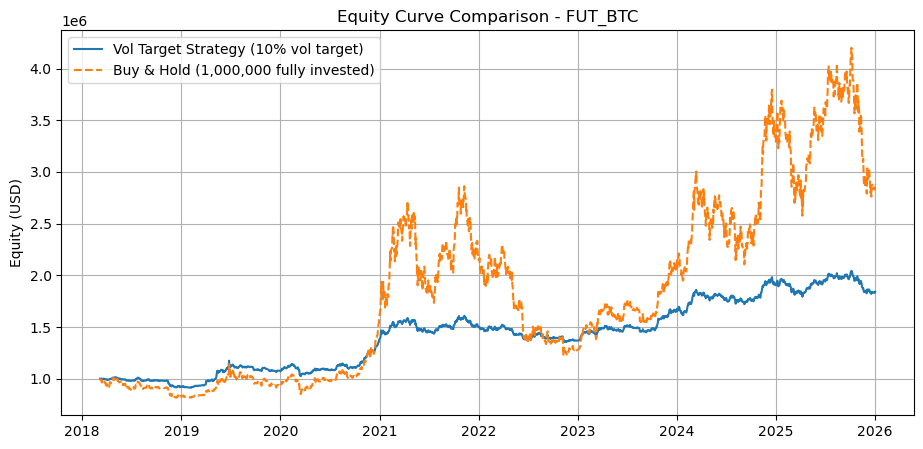


===== FUT_E6 =====
Strategy Sharpe: -0.397 | MaxDD: -62.303%
Buy&Hold Sharpe: -0.232 | MaxDD: -42.309%
Turnover total: 234 | avg: 0.052 | ratio: 0.010


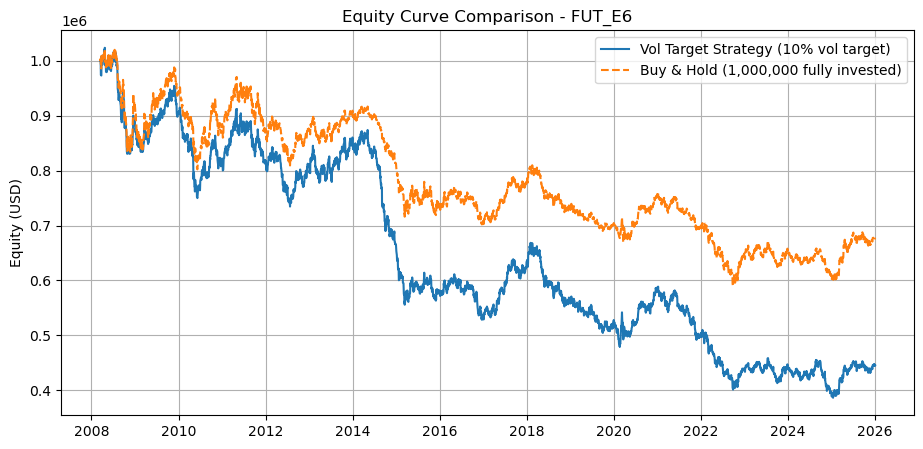


===== FUT_ES =====
Strategy Sharpe: 0.652 | MaxDD: -19.619%
Buy&Hold Sharpe: 0.593 | MaxDD: -42.489%
Turnover total: 331 | avg: 0.074 | ratio: 0.008


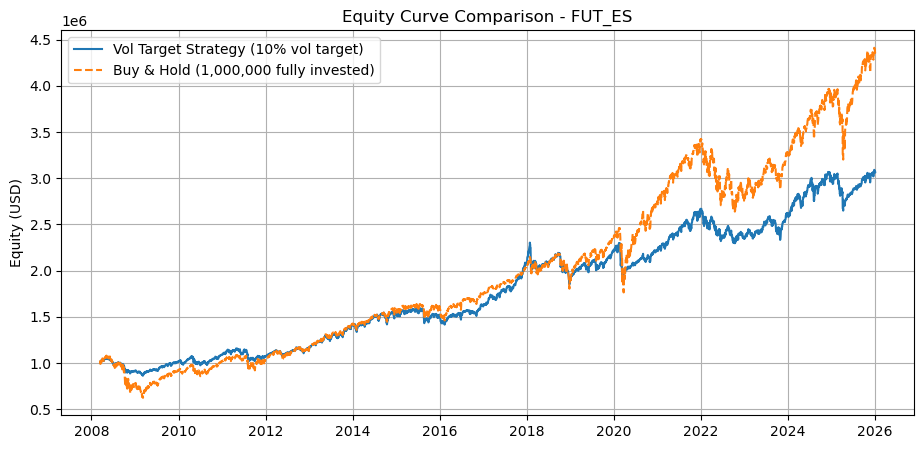


===== FUT_FDAX =====
Strategy Sharpe: 0.352 | MaxDD: -19.971%
Buy&Hold Sharpe: 0.422 | MaxDD: -40.746%
Turnover total: 138 | avg: 0.031 | ratio: 0.011


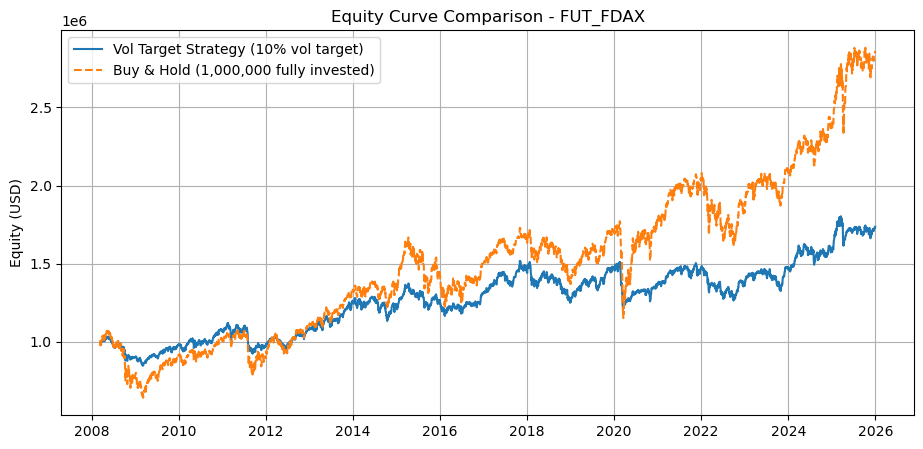


===== FUT_FGBL =====
Strategy Sharpe: 0.520 | MaxDD: -38.439%
Buy&Hold Sharpe: 0.492 | MaxDD: -26.837%
Turnover total: 416 | avg: 0.093 | ratio: 0.003


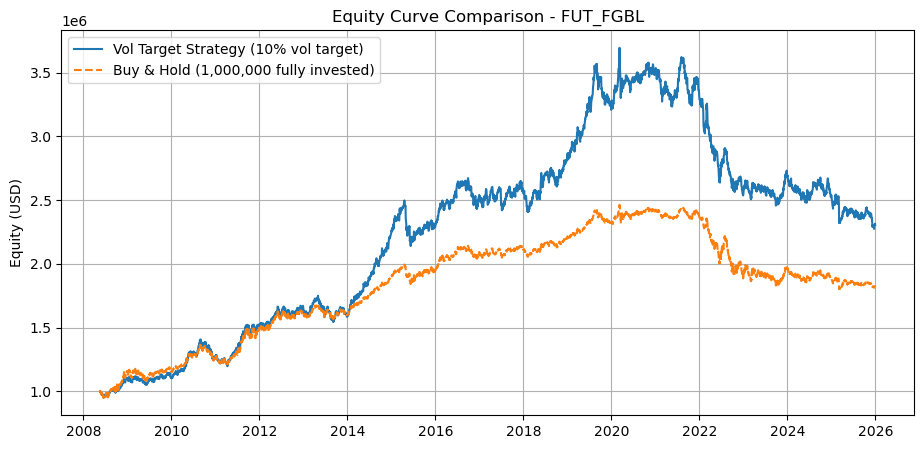


===== FUT_GC =====
Strategy Sharpe: 0.476 | MaxDD: -35.579%
Buy&Hold Sharpe: 0.496 | MaxDD: -36.132%
Turnover total: 238 | avg: 0.053 | ratio: 0.010


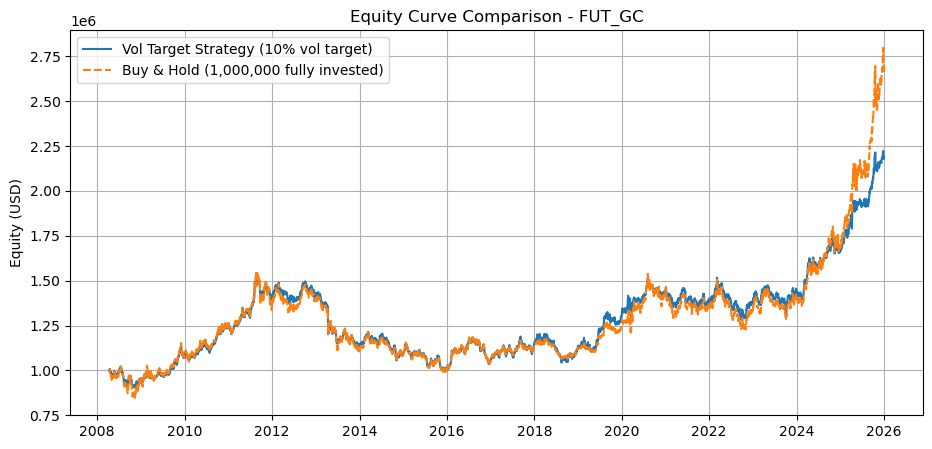


===== FUT_J7 =====
Strategy Sharpe: -0.498 | MaxDD: -70.145%
Buy&Hold Sharpe: -0.367 | MaxDD: -57.827%
Turnover total: 248 | avg: 0.055 | ratio: 0.008


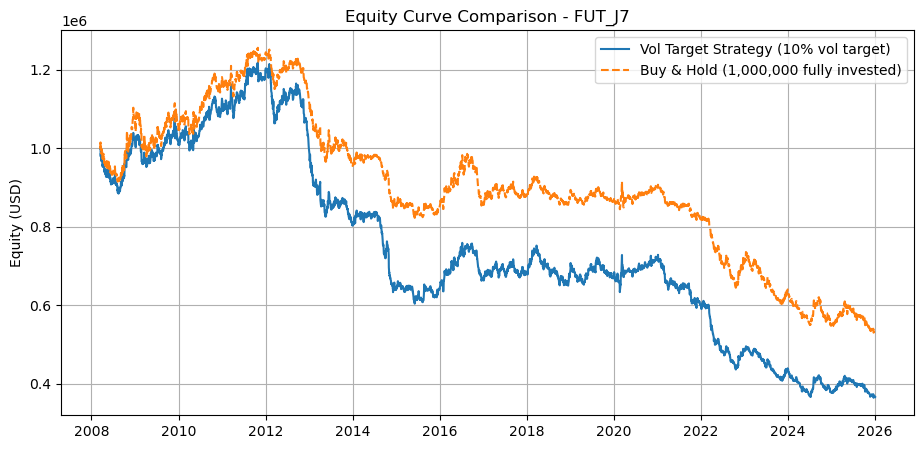


===== FUT_VX =====
Strategy Sharpe: -0.238 | MaxDD: -67.646%
Buy&Hold Sharpe: -0.308 | MaxDD: -93.546%
Turnover total: 294 | avg: 0.068 | ratio: 0.013


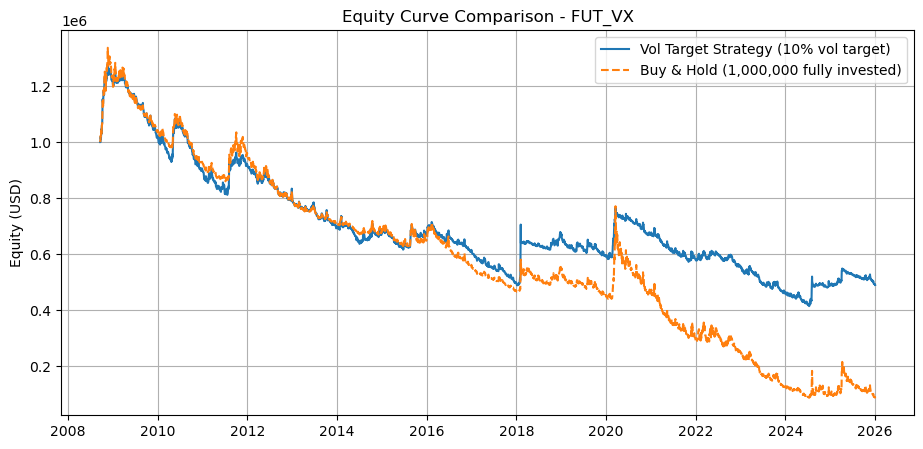


===== FUT_ZF =====
Strategy Sharpe: 0.150 | MaxDD: -43.270%
Buy&Hold Sharpe: 0.260 | MaxDD: -17.468%
Turnover total: 651 | avg: 0.145 | ratio: 0.004


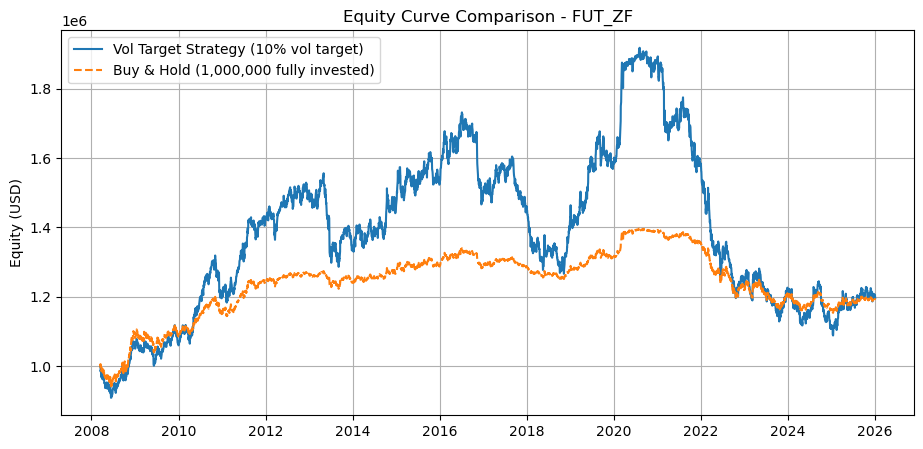


===== STK_JPM =====
Strategy Sharpe: -0.023 | MaxDD: -26.520%
Buy&Hold Sharpe: 0.024 | MaxDD: -17.471%
Turnover total: 907072 | avg: 319.167 | ratio: 0.006


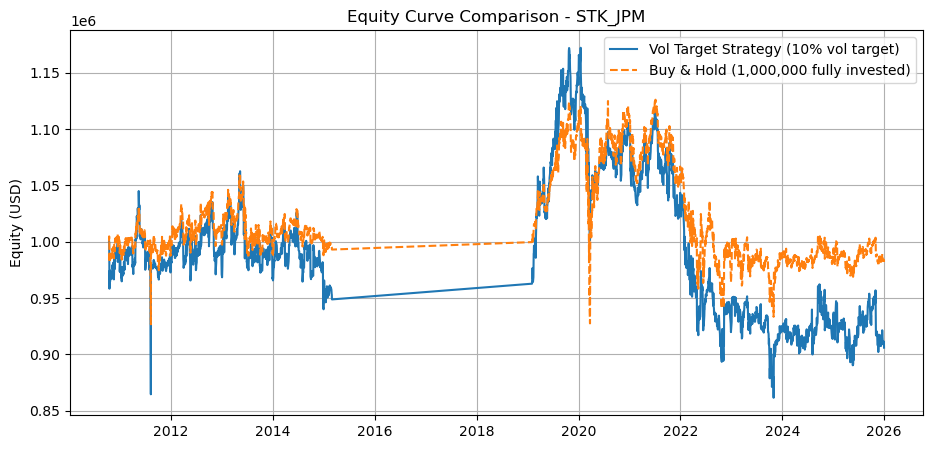


===== STK_LLY =====
Strategy Sharpe: 0.635 | MaxDD: -32.281%
Buy&Hold Sharpe: 0.621 | MaxDD: -70.270%
Turnover total: 294080 | avg: 45.327 | ratio: 0.004


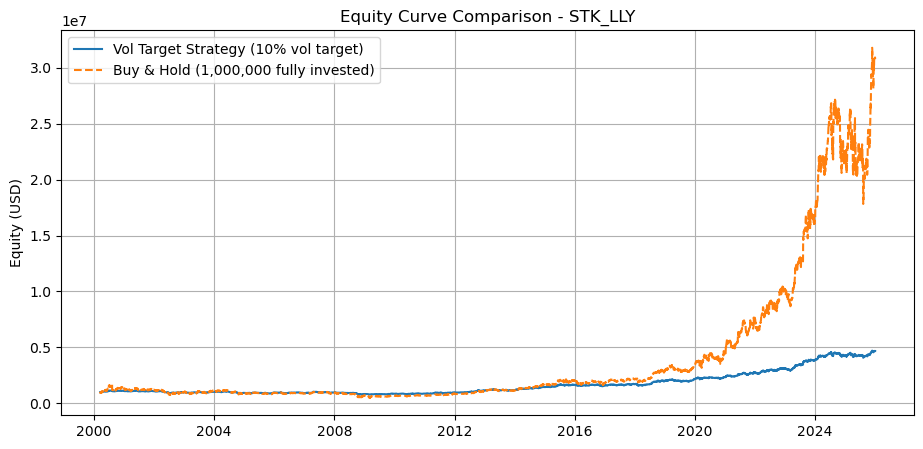


===== STK_NVDA =====
Strategy Sharpe: 0.860 | MaxDD: -22.649%
Buy&Hold Sharpe: 0.755 | MaxDD: -89.724%
Turnover total: 35538781 | avg: 5477.617 | ratio: 0.008


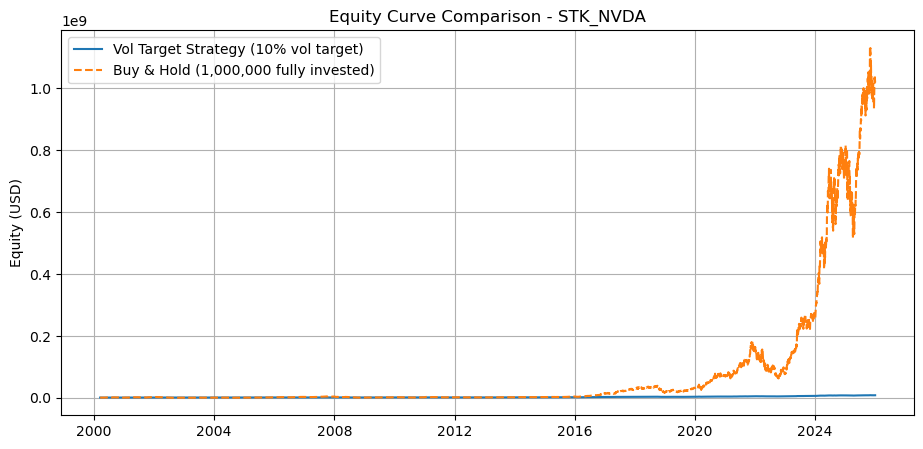


===== STK_TSLA =====
Strategy Sharpe: 0.872 | MaxDD: -17.291%
Buy&Hold Sharpe: 0.947 | MaxDD: -73.632%
Turnover total: 970086 | avg: 251.905 | ratio: 0.009


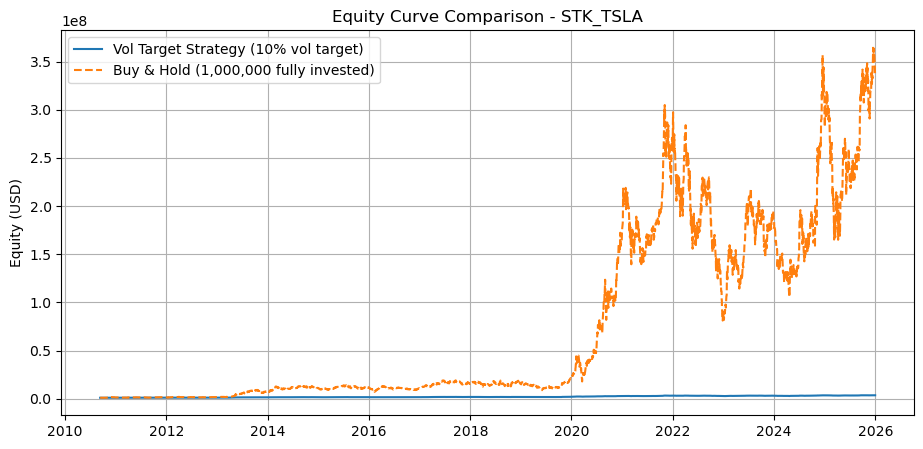


===== STK_XOM =====
Strategy Sharpe: 0.368 | MaxDD: -35.282%
Buy&Hold Sharpe: 0.406 | MaxDD: -62.396%
Turnover total: 427370 | avg: 65.871 | ratio: 0.004


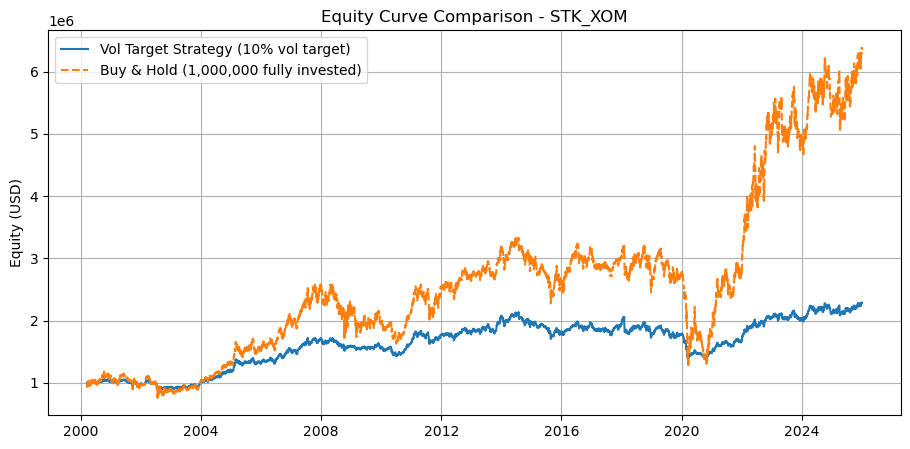

In [40]:

#FUNDAMENTAL PLOTS and METRICS

def max_drawdown(equity: pd.Series) -> float:
    e = equity.astype(float).dropna()
    if e.empty:
        return np.nan
    peak = e.cummax()
    dd = e / peak - 1.0
    return float(dd.min())

def sharpe(sr: pd.Series, periods_per_year: int = 252) -> float:
    r = sr.astype(float).dropna()
    if len(r) < 2:
        return np.nan
    sd = r.std(ddof=1)
    if sd == 0 or np.isnan(sd):
        return np.nan
    return float(np.sqrt(periods_per_year) * r.mean() / sd)

capital = 1_000_000

for asset in sorted(bt_1d.keys()):

    bt = bt_1d[asset].copy().sort_index()

    price = bt["close"].astype(float).dropna()
    strat_equity = bt["equity_usd"].astype(float).dropna()

    idx = price.index.intersection(strat_equity.index)

    price = price.loc[idx]
    strat_equity = strat_equity.loc[idx]

    bh_equity = capital * (price / price.iloc[0])

    strat_ret = strat_equity.pct_change()
    bh_ret = bh_equity.pct_change()

    strat_sh = sharpe(strat_ret)
    bh_sh = sharpe(bh_ret)

    strat_dd = max_drawdown(strat_equity)
    bh_dd = max_drawdown(bh_equity)

    trades = bt["trade"].abs()
    avg_pos = bt["contracts"].abs().mean()

    total_turnover = trades.sum()
    avg_turnover = trades.mean()

    turnover_ratio = total_turnover / (avg_pos * len(bt)) if avg_pos > 0 else np.nan

    print(f"\n===== {asset} =====")
    print(f"Strategy Sharpe: {strat_sh:.3f} | MaxDD: {strat_dd:.3%}")
    print(f"Buy&Hold Sharpe: {bh_sh:.3f} | MaxDD: {bh_dd:.3%}")
    print(f"Turnover total: {total_turnover:.0f} | avg: {avg_turnover:.3f} | ratio: {turnover_ratio:.3f}")

    plt.figure(figsize=(11,5))
    plt.plot(strat_equity, label="Vol Target Strategy (10% vol target)")
    plt.plot(bh_equity, label="Buy & Hold (1,000,000 fully invested)", linestyle="--")
    plt.title(f"Equity Curve Comparison - {asset}")
    plt.ylabel("Equity (USD)")
    plt.grid(True)
    plt.legend()
    plt.show()

## Interpreting the results

The backtest shows that the model is effective mainly from a risk management perspective. In several assets, targeting a 10% annualized volatility improves the overall profile of returns, especially by reducing drawdowns. In some cases, it also leads to a higher Sharpe ratio.

However, for assets with structurally low or negative returns, such as EUR/USD, performance tends to deteriorate. This happens because these assets usually have a volatility lower than the 10% target under a buy-and-hold approach. As a result, volatility targeting increases leverage, which raises risk without improving returns.

From a structural point of view, this effect is particularly clear in FX markets, where returns are generally low and often driven by carry or mean-reverting behavior. In these cases, the model increases exposure to an asset that does not have a strong or persistent risk premium, effectively amplifying noise rather than signal.

More generally, volatility targeting should be seen as a tool to control and standardize risk, rather than a method to increase returns. Its main role is to make the distribution of returns more stable over time, not to generate additional alpha.

The effectiveness of this approach also depends on the type of asset. It tends to work better in markets where volatility is more persistent and reflects underlying risk conditions, such as equities or crypto. In contrast, its benefits are less clear in markets where volatility is more unstable or mean-reverting.

Overall, this type of model is useful for managing exposure in a consistent way. When combined with portfolio construction methods, such as weighting schemes based on bootstrapping, it allows for a more stable and controlled level of risk.

This is particularly relevant in systematic strategies, both for single strategies and, even more, in multi-strategy portfolios, where keeping risk stable over time is a key requirement.

### Realized Variance proxy


$$
RV_t = r_t^2
$$

with $r_t \sim \mathcal{N}(0, \sigma_t^2)$, implying:

$$
\mathbb{E}[r_t^2] = \sigma_t^2
$$

This provides an unbiased but noisy proxy of realized variance.

In [41]:
def add_realized_variance_to_universe(
    universe: dict,
    ret_col: str = "return",
    rv_col: str = "rv"
) -> dict:
    out = {}

    for name, df in universe.items():
        x = df.copy()

        if ret_col not in x.columns:
            raise ValueError(f"{name}: manca la colonna '{ret_col}'")

        r = x[ret_col].astype(float).replace([np.inf, -np.inf], np.nan)

        # Proxy di realized variance:
        # RV_t = r_t^2
        x[rv_col] = r ** 2

        out[name] = x

    return out

df_instruments_1d = add_realized_variance_to_universe(
    df_instruments_1d,
    ret_col="return",
    rv_col="rv"
)

## Two-Factor Kalman Filter for Log-Volatility

We model log-realized variance using a two-factor linear Gaussian state-space model:

$$
h_t = F h_{t-1} + \eta_t
$$

$$
y_t = \mu + H h_t + \varepsilon_t
$$

Where $h_t = [h^{(s)}_t, h^{(l)}_t]'$ is the latent state vector. $h^{(s)}_t$ defines the short-term volatility component and $h^{(l)}_t$ the long-term volatility component.  
$y_t = \log(RV_t)$ is the observed log-realized variance. $\eta_t \sim \mathcal{N}(0, Q)$ is state noise and $\varepsilon_t \sim \mathcal{N}(0, R)$ is observation noise. 

**System Matrices**
$$
F =
\begin{bmatrix}
\phi_s & 0 \\
0 & \phi_l
\end{bmatrix}
\quad
H =
\begin{bmatrix}
1 & 1
\end{bmatrix}
$$
$$
Q =
\begin{bmatrix}
q_s & 0 \\
0 & q_l
\end{bmatrix}
\quad
R = [r]
$$
- $\phi_s$ controls short-term persistence  
- $\phi_l$ controls long-term persistence (typically close to 1)  
- $q_s, q_l$ determine volatility of the latent components  
- $r$ captures measurement noise in realized variance  

**Prediction Step**

$$
x_{t|t-1} = F x_{t-1|t-1}
$$
This equation represents the conditional prediction of the latent state at time $t$ given the information up to time $t-1$. Where $x_{t|t-1}$ is the expected value of the state at time $t$ given the past and $x_{t-1|t-1}$ is the filtered state at time $t-1$. In practice, it takes the diagonal matrix $F$ multiplying it by the expected value of the state at time $t-1$. In this way we make the first prediction step. 

$$
P_{t|t-1} = F P_{t-1|t-1} F' + Q
$$
This equation represents the conditional covariance of the state prediction error. In the equation we have $P_{t|t-1}$ that is the covariance of the forecast error and $P_{t-1|t-1}$ is the covariance of the filtered state. This is fundamental because represents uncertainty in the latent state. 

**Observation Prediction**

$$
\hat{y}_t = \mu + H x_{t|t-1}
$$
This equation represents the conditional forecast of the observation at time $t$. Here we are calculating the conditioned observation forecast $\hat{y}_t$. For making this we add the mean observation level $\mu$ to the observation matrix $H$ multiplied by the conditional prediction $x_{t|t-1}$ calculated before. 

$$
S_t = H P_{t|t-1} H' + R
$$
This equation is one of the most interesting parts of the model because it computes the variance of the prediction error. Here we multiply the predicted state covariance $P_{t|t-1}$ by the observation matrix $H$, and then by its transpose. We also add the observation noise variance. 

**Update Step**

Innovation:
$$
\nu_t = y_t - \hat{y}_t
$$
$\nu_t$ is the innovation (forecast error), calculated simply by subtracting $\hat{y}_t$ from $y_t$. 

Kalman gain:
$$
K_t = P_{t|t-1} H' S_t^{-1}
$$
This is a crucial part of the framework. Kalman gain determines how much the innovation modifies the state, it allows us to understand the balance between the model and data. Note that here the inverse of the forecast error variance is used. That's why the optimal solution needs to weight the error as a function of its uncertainty. 

State update:
$$
x_{t|t} = x_{t|t-1} + K_t \nu_t
$$
The filtered state $x_{t|t}$ represents the best estimate after the observation is integrated. Here we add the predicted state $x_{t|t-1}$ to the Kalman gain $K_t$ multiplied by the innovation. 

Covariance update (Joseph form):
$$
P_{t|t} = (I - K_t H) P_{t|t-1} (I - K_t H)' + K_t R K_t'
$$
Here the calculation for the filtered state covariance is given by the Joseph covariance formula. In the referenced literature the covariance update is typically expressed in its compact form. However, in this implementation we tried to ensure better numerical stability.  
Moreover, while the compact form is often used for theoretical demonstrations, this form is more used in computational and practical frameworks. 

**Log-Likelihood**

The contribution to the Gaussian log-likelihood at time $t$ is:
$$
\ell_t = -\frac{1}{2} \left( \log(2\pi) + \log S_t + \frac{\nu_t^2}{S_t} \right)
$$
Where $\ell_t$ is the individual contribution to the log-likelihood at time $t$.  
We used this form because it comes directly from the PDF of the normal distribution. 

Total log-likelihood:
$$
\mathcal{L} = \sum_t \ell_t
$$

**Initialization**

Manual initialization: 
- $x_0$: starting system state  
- $P_0$: starting state covariance, chosen arbitrarily  

Stationary initialization:
$$
\text{Var}(h_i) = \frac{q_i}{1 - \phi_i^2}
$$
Where $\text{Var}(h_i)$ is the variance of the state component. $q_i$ is the state noise variance and $\phi_i$ is the persistence parameter. This calculation ensures consistency with the implied stationary distribution of the AR(1) process. 

**Forecasting**

Multi-step forecasts are obtained recursively:
$$
x_{t+h} = F^h x_t
$$
This simple equation finds the predicted state at horizon $h$ by multiplying the transition matrix elevated to $h$ for $x_t$ that has all the available information. 

$$
\hat{y}_{t+h} = \mu + H x_{t+h}
$$
Where $\hat{y}_{t+h}$ is the observed forecast at horizon $h$. Here we use again $\mu$, which ensures that the forecast is correctly centered. We add to $\mu$ the multiplication of the observation matrix and the predicted state of the previous equation. 

Forecast uncertainty:
$$
S_{t+h} = H P_{t+h} H' + R
$$
Here we are calculating the final predicted variance at horizon $h$, which measures the uncertainty associated with the future prediction. Here we multiply the observation matrix for the predicted state covariance $P_{t+h}$ at horizon $h$, multiplied again for the transpose of the observation matrix, all added by the observation noise.

**Key Properties**
- Uses log-realized variance → stabilizes variance and ensures positivity  
- Separates volatility into short-term and long-term components  
- Produces **ex-ante forecasts** of volatility  
- Fully probabilistic → supports likelihood-based estimation  
- Naturally handles missing or noisy observations  

**Model considerations:**
The model allows us to have information not just based on the Realized Variance as in the EWMA, but also with the observation noise. Theoretically, this is better than a simple model such as the EWMA. However, in the next part of the research, we will observe that more precision, or more fitting, is not always a positive feature.  

In [42]:
#KALMAN FILTER MODEL 

@dataclass
class KalmanRVConfig:
    mu: float = 0.0            
    phi_s: float = 0.50        
    phi_l: float = 0.985       
    q_s: float = 1e-5          
    q_l: float = 1e-4          
    r: float = 1e-2            


class KalmanRV2Factor:

    def __init__(self, config: KalmanRVConfig):
        self.config = config

        # Stato iniziale
        self.x = np.zeros((2, 1), dtype=float)

        # Covarianza iniziale
        self.P = np.eye(2, dtype=float)

        self._rebuild_system_matrices()
        self._validate_parameters()

        self.parameter_history: List[Dict[str, Any]] = []
        self._log_parameter_snapshot(event="init")

    def _validate_parameters(self) -> None:
        cfg = self.config

        if not (-0.999 < cfg.phi_s < 0.999):
            raise ValueError(f"phi_s deve stare in (-1, 1). Trovato: {cfg.phi_s}")

        if not (-0.999 < cfg.phi_l < 0.999):
            raise ValueError(f"phi_l deve stare in (-1, 1). Trovato: {cfg.phi_l}")

        if cfg.q_s <= 0:
            raise ValueError(f"q_s deve essere > 0. Trovato: {cfg.q_s}")

        if cfg.q_l <= 0:
            raise ValueError(f"q_l deve essere > 0. Trovato: {cfg.q_l}")

        if cfg.r <= 0:
            raise ValueError(f"r deve essere > 0. Trovato: {cfg.r}")

    def _rebuild_system_matrices(self) -> None:
        cfg = self.config

        self.F = np.array([
            [cfg.phi_s, 0.0],
            [0.0, cfg.phi_l]
        ], dtype=float)

        self.H = np.array([[1.0, 1.0]], dtype=float)

        self.Q = np.array([
            [cfg.q_s, 0.0],
            [0.0, cfg.q_l]
        ], dtype=float)

        self.R = np.array([[cfg.r]], dtype=float)

    def _symmetrize(self, M: np.ndarray) -> np.ndarray:
        return 0.5 * (M + M.T)

    def _safe_scalar(self, x: Any) -> float:
        return float(np.asarray(x).squeeze())

    def _log_parameter_snapshot(
        self,
        event: str,
        extra: Optional[Dict[str, Any]] = None
    ) -> None:
        row = {
            "event": event,
            "mu": self.config.mu,
            "phi_s": self.config.phi_s,
            "phi_l": self.config.phi_l,
            "q_s": self.config.q_s,
            "q_l": self.config.q_l,
            "r": self.config.r,
            "h_short_0": float(self.x[0, 0]),
            "h_long_0": float(self.x[1, 0]),
            "p_short_0": float(self.P[0, 0]),
            "p_long_0": float(self.P[1, 1]),
        }
        if extra:
            row.update(extra)
        self.parameter_history.append(row)

    def get_parameter_history(self) -> pd.DataFrame:
        return pd.DataFrame(self.parameter_history)

    def count_parameter_modifications(self) -> int:
        return int(sum(row["event"] == "update_parameters" for row in self.parameter_history))

    def count_all_state_resets(self) -> int:
        return int(sum(row["event"] == "set_initial_state" for row in self.parameter_history))

    def get_total_qlike_trials(self, manual_extra_trials: int = 30) -> int:
        logged_trials = self.count_parameter_modifications()
        return int(logged_trials + manual_extra_trials)

    def current_state(self) -> Dict[str, float]:
        latent_log_vol = self._safe_scalar(self.config.mu + self.H @ self.x)
        return {
            "h_short": float(self.x[0, 0]),
            "h_long": float(self.x[1, 0]),
            "latent_log_vol": latent_log_vol,
        }

    def current_parameters(self) -> Dict[str, float]:
        return asdict(self.config)

    def set_initial_state(
        self,
        h_short_0: float = 0.0,
        h_long_0: float = 0.0,
        p_short_0: float = 1.0,
        p_long_0: float = 1.0
    ) -> None:
        if p_short_0 <= 0 or p_long_0 <= 0:
            raise ValueError("Le varianze iniziali devono essere > 0.")

        self.x = np.array([[h_short_0],
                           [h_long_0]], dtype=float)

        self.P = np.array([[p_short_0, 0.0],
                           [0.0, p_long_0]], dtype=float)
        self.P = self._symmetrize(self.P)

        self._log_parameter_snapshot(event="set_initial_state")

    def set_stationary_initial_state(
        self,
        h_short_0: float = 0.0,
        h_long_0: float = 0.0,
        scale: float = 1.0
    ) -> None:
        
        if scale <= 0:
            raise ValueError("scale deve essere > 0.")

        cfg = self.config
        p_short = scale * cfg.q_s / (1.0 - cfg.phi_s ** 2)
        p_long = scale * cfg.q_l / (1.0 - cfg.phi_l ** 2)

        self.set_initial_state(
            h_short_0=h_short_0,
            h_long_0=h_long_0,
            p_short_0=p_short,
            p_long_0=p_long
        )

    def update_parameters(
        self,
        mu: Optional[float] = None,
        phi_s: Optional[float] = None,
        phi_l: Optional[float] = None,
        q_s: Optional[float] = None,
        q_l: Optional[float] = None,
        r: Optional[float] = None
    ) -> None:
        if mu is not None:
            self.config.mu = float(mu)
        if phi_s is not None:
            self.config.phi_s = float(phi_s)
        if phi_l is not None:
            self.config.phi_l = float(phi_l)
        if q_s is not None:
            self.config.q_s = float(q_s)
        if q_l is not None:
            self.config.q_l = float(q_l)
        if r is not None:
            self.config.r = float(r)

        self._rebuild_system_matrices()
        self._validate_parameters()
        self._log_parameter_snapshot(event="update_parameters")

    def transform_observation(self, rv_t: float) -> float:
        if not np.isfinite(rv_t):
            raise ValueError("rv_t deve essere finita.")
        if rv_t <= 0:
            raise ValueError("RV_t deve essere strettamente positiva per usare log(RV_t).")
        return float(np.log(rv_t))
    
    def predict_state(self) -> Dict[str, np.ndarray]:
        """
        Predizione dello stato e della sua covarianza:
            x_{t|t-1}, P_{t|t-1}
        """
        x_pred = self.F @ self.x
        P_pred = self.F @ self.P @ self.F.T + self.Q
        P_pred = self._symmetrize(P_pred)

        return {
            "x_pred": x_pred,
            "P_pred": P_pred,
        }

    def predict_one_step(self) -> Dict[str, Any]:
     
        st = self.predict_state()
        x_pred = st["x_pred"]
        P_pred = st["P_pred"]

        y_pred = self._safe_scalar(self.config.mu + self.H @ x_pred)
        S = self._safe_scalar(self.H @ P_pred @ self.H.T + self.R)

        if S <= 0:
            raise RuntimeError(f"Variance of prediction error non positiva: S={S}")

        return {
            "x_pred": x_pred,
            "P_pred": P_pred,
            "y_pred": y_pred,
            "S": S,
        }

    def _update_from_log_observation(self, y_t: float) -> Dict[str, Any]:
       
        if not np.isfinite(y_t):
            raise ValueError("y_t deve essere finita.")

        pred = self.predict_one_step()
        x_pred = pred["x_pred"]
        P_pred = pred["P_pred"]
        y_pred = pred["y_pred"]
        S = pred["S"]

        innovation = float(y_t - y_pred)
        K = P_pred @ self.H.T / S   # shape (2,1)

        # filtered state
        x_filt = x_pred + K * innovation

        I = np.eye(2, dtype=float)
        KH = K @ self.H
        P_filt = (I - KH) @ P_pred @ (I - KH).T + K @ self.R @ K.T
        P_filt = self._symmetrize(P_filt)

        self.x = x_filt
        self.P = P_filt

        latent_log_vol = self._safe_scalar(self.config.mu + self.H @ self.x)

        loglik_t = -0.5 * (
            np.log(2.0 * np.pi) +
            np.log(S) +
            (innovation ** 2) / S
        )

        return {
            "y_t": float(y_t),
            "x_pred": x_pred.copy(),
            "P_pred": P_pred.copy(),
            "y_pred": float(y_pred),
            "innovation": float(innovation),
            "S": float(S),
            "K": K.copy(),
            "x_filt": x_filt.copy(),
            "P_filt": P_filt.copy(),
            "h_short": float(x_filt[0, 0]),
            "h_long": float(x_filt[1, 0]),
            "latent_log_vol": float(latent_log_vol),
            "loglik_t": float(loglik_t),
        }

    def update_from_rv(self, rv_t: float) -> Dict[str, Any]:
        y_t = self.transform_observation(rv_t)
        out = self._update_from_log_observation(y_t)
        out["rv_t"] = float(rv_t)
        return out

    def update_from_log_rv(self, log_rv_t: float) -> Dict[str, Any]:
        out = self._update_from_log_observation(float(log_rv_t))
        out["rv_t"] = float(np.exp(log_rv_t))
        return out

    # backward compatibility
    def predict(self) -> Dict[str, Any]:
        return self.predict_one_step()

    def update(self, rv_t: float) -> Dict[str, Any]:
        return self.update_from_rv(rv_t)

    def filter_series(
        self,
        rv_series: pd.Series,
        reset_state: bool = False,
        initial_state: Optional[Dict[str, float]] = None,
        use_stationary_init: bool = False
    ) -> pd.DataFrame:
        """
        Filtra una serie di RV_t positive.
        Restituisce per ogni t:
        - previsione ex-ante y_pred
        - stato predetto e filtrato
        - innovazione
        - log-likelihood contribution
        """
        rv_series = rv_series.dropna().astype(float)
        rv_series = rv_series[np.isfinite(rv_series)]
        rv_series = rv_series[rv_series > 0].copy()

        if reset_state:
            if initial_state is not None:
                self.set_initial_state(
                    h_short_0=initial_state.get("h_short_0", 0.0),
                    h_long_0=initial_state.get("h_long_0", 0.0),
                    p_short_0=initial_state.get("p_short_0", 1.0),
                    p_long_0=initial_state.get("p_long_0", 1.0),
                )
            elif use_stationary_init:
                self.set_stationary_initial_state()
            else:
                self.set_initial_state()

        rows = []
        for t, rv_t in rv_series.items():
            out = self.update_from_rv(float(rv_t))
            out["time"] = t
            rows.append(out)

        if not rows:
            return pd.DataFrame()

        return pd.DataFrame(rows).set_index("time")

    def filter_log_series(
        self,
        log_rv_series: pd.Series,
        reset_state: bool = False,
        initial_state: Optional[Dict[str, float]] = None,
        use_stationary_init: bool = False
    ) -> pd.DataFrame:
        """
        Filtra una serie che è già log(RV_t).
        """
        y = log_rv_series.dropna().astype(float)
        y = y[np.isfinite(y)].copy()

        if reset_state:
            if initial_state is not None:
                self.set_initial_state(
                    h_short_0=initial_state.get("h_short_0", 0.0),
                    h_long_0=initial_state.get("h_long_0", 0.0),
                    p_short_0=initial_state.get("p_short_0", 1.0),
                    p_long_0=initial_state.get("p_long_0", 1.0),
                )
            elif use_stationary_init:
                self.set_stationary_initial_state()
            else:
                self.set_initial_state()

        rows = []
        for t, y_t in y.items():
            out = self.update_from_log_rv(float(y_t))
            out["time"] = t
            rows.append(out)

        if not rows:
            return pd.DataFrame()

        return pd.DataFrame(rows).set_index("time")

    def forecast_logrv_path(
        self,
        steps: int
    ) -> pd.DataFrame:
       
        if steps <= 0:
            raise ValueError("steps deve essere >= 1")

        x = self.x.copy()
        P = self.P.copy()

        rows = []
        for h in range(1, steps + 1):
            x = self.F @ x
            P = self.F @ P @ self.F.T + self.Q
            P = self._symmetrize(P)

            y_pred = self._safe_scalar(self.config.mu + self.H @ x)
            S = self._safe_scalar(self.H @ P @ self.H.T + self.R)

            rows.append({
                "horizon": h,
                "y_pred": float(y_pred),
                "var_pred_error": float(S),
                "h_short_pred": float(x[0, 0]),
                "h_long_pred": float(x[1, 0]),
            })

        return pd.DataFrame(rows).set_index("horizon")

    def loglikelihood(
        self,
        rv_series: pd.Series,
        reset_state: bool = True,
        initial_state: Optional[Dict[str, float]] = None,
        use_stationary_init: bool = True
    ) -> float:
       
        filt = self.filter_series(
            rv_series=rv_series,
            reset_state=reset_state,
            initial_state=initial_state,
            use_stationary_init=use_stationary_init
        )

        if filt.empty:
            return float("nan")

        return float(filt["loglik_t"].sum())

    def negative_loglikelihood(
        self,
        rv_series: pd.Series,
        reset_state: bool = True,
        initial_state: Optional[Dict[str, float]] = None,
        use_stationary_init: bool = True
    ) -> float:
        ll = self.loglikelihood(
            rv_series=rv_series,
            reset_state=reset_state,
            initial_state=initial_state,
            use_stationary_init=use_stationary_init
        )
        return float(-ll)

In [43]:

def qlike_pointwise(y_true: pd.Series, y_pred: pd.Series, eps: float = 1e-12) -> pd.Series:
    yt = y_true.astype(float).clip(lower=eps)
    yp = y_pred.astype(float).clip(lower=eps)

    mask = yt.notna() & yp.notna()
    out = pd.Series(index=yt.index, dtype=float)

    ratio = yt.loc[mask] / yp.loc[mask]
    out.loc[mask] = ratio - np.log(ratio) - 1.0

    return out

def expanding_metrics_by_year_universe_kalman(
    universe: dict,
    rv_col: str = "rv",
    kalman_pred_col: str = "kalman_rv_pred",
    min_obs_total: int = 200,
    drop_first_n: int = 0,
    var_floor: float = 1e-12
) -> pd.DataFrame:

    rows = []

    for inst, df in universe.items():

        if rv_col not in df.columns:
            raise ValueError(f"{inst}: missing '{rv_col}'")

        if kalman_pred_col not in df.columns:
            raise ValueError(f"{inst}: missing '{kalman_pred_col}'")

        x = df[[rv_col, kalman_pred_col]].copy()

        if drop_first_n > 0:
            x = x.iloc[drop_first_n:]

        y_true_var = x[rv_col].astype(float).clip(lower=var_floor)
        y_pred_var = x[kalman_pred_col].astype(float).clip(lower=var_floor)

        ql_pt = qlike_pointwise(y_true_var, y_pred_var)

        tmp = pd.DataFrame({
            "qlike_pt": ql_pt
        }).dropna(subset=["qlike_pt"])

        if tmp.empty:
            continue

        years = sorted(tmp.index.year.unique())

        for year in years:
            g = tmp.loc[tmp.index.year <= year]
            n = len(g)

            if n < min_obs_total:
                continue

            qlike_exp = float(g["qlike_pt"].mean())

            rows.append({
                "instrument": inst,
                "year": int(year),
                "n_obs": int(n),
                "QLIKE_expanding": qlike_exp
            })

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    return out.sort_values(["instrument", "year"]).reset_index(drop=True)

def senior_mean_by_year(
    df_metrics: pd.DataFrame,
    qlike_col: str,
    min_instruments: int = 5
) -> pd.DataFrame:

    if df_metrics.empty:
        return pd.DataFrame(columns=["year", "n_instruments", "QLIKE_SENIOR"])

    g = (
        df_metrics.groupby("year")
        .agg(
            n_instruments=("instrument", "nunique"),
            QLIKE_SENIOR=(qlike_col, "mean"),
        )
        .reset_index()
    )

    g = (
        g[g["n_instruments"] >= min_instruments]
        .sort_values("year")
        .reset_index(drop=True)
    )

    return g

def add_kalman_to_universe(
    universe: dict,
    config: KalmanRVConfig = None,
    rv_col: str = "rv",
    min_obs: int = 30,
    reset_state: bool = True,
    use_stationary_init: bool = True,
    initial_state: dict | None = None,
    verbose: bool = True
) -> dict:

    if config is None:
        config = KalmanRVConfig()

    out = {}
    skipped = []

    for inst, df in universe.items():

        if not isinstance(df, pd.DataFrame):
            skipped.append((inst, "not a DataFrame"))
            continue

        x = df.copy()

        if rv_col not in x.columns:
            skipped.append((inst, f"missing '{rv_col}'"))
            continue

        rv = (
            x[rv_col]
            .astype(float)
            .replace([np.inf, -np.inf], np.nan)
            .replace(0.0, np.nan)
            .dropna()
        )

        rv = rv[rv > 0]

        if len(rv) < min_obs:
            skipped.append((inst, f"too few observations ({len(rv)})"))
            continue

        model = KalmanRV2Factor(config)

        filt = model.filter_series(
            rv_series=rv,
            reset_state=reset_state,
            initial_state=initial_state,
            use_stationary_init=use_stationary_init
        )

        if filt.empty:
            skipped.append((inst, "empty filter"))
            continue

        x["kalman_logrv"] = np.nan
        x["kalman_rv"] = np.nan
        x["kalman_rv_pred"] = np.nan
        x["kalman_innovation"] = np.nan

        common_idx = x.index.intersection(filt.index)

        x.loc[common_idx, "kalman_logrv"] = filt.loc[common_idx, "latent_log_vol"]
        x.loc[common_idx, "kalman_rv"] = np.exp(filt.loc[common_idx, "latent_log_vol"])
        x.loc[common_idx, "kalman_rv_pred"] = np.exp(filt.loc[common_idx, "y_pred"])
        x.loc[common_idx, "kalman_innovation"] = filt.loc[common_idx, "innovation"]

        out[inst] = x

    if verbose and skipped:
        print("Strumenti saltati:")
        for inst, msg in skipped:
            print(f" - {inst} -> {msg}")

    return out

df_1d_with_kalman = add_kalman_to_universe(
    universe=df_instruments_1d,
    config=KalmanRVConfig(),
    min_obs=30,
    reset_state=True,
    use_stationary_init=True
)

exp_kalman_1d = expanding_metrics_by_year_universe_kalman(
    universe=df_1d_with_kalman,
    rv_col="rv",
    kalman_pred_col="kalman_rv_pred",
    min_obs_total=200,
    drop_first_n=50
)

senior_kalman_1d = senior_mean_by_year(
    exp_kalman_1d,
    qlike_col="QLIKE_expanding",
    min_instruments=5
)

print("\n--- PER-ASSET ---")

for inst in exp_kalman_1d["instrument"].unique():
    df_inst = exp_kalman_1d[exp_kalman_1d["instrument"] == inst]
    print(f"\nInstrument: {inst}")
    print(df_inst[["year", "n_obs", "QLIKE_expanding"]].to_string(index=False))

print("\n--- SUMMARY LAST YEAR ---")

last_year = exp_kalman_1d["year"].max()

summary_last = (
    exp_kalman_1d[exp_kalman_1d["year"] == last_year]
    .sort_values("QLIKE_expanding")
)

print(summary_last[["instrument", "QLIKE_expanding"]].to_string(index=False))

print("\n--- SENIOR ---")
print(senior_kalman_1d)


--- PER-ASSET ---

Instrument: FUT_BTC
 year  n_obs  QLIKE_expanding
 2018    204         2.102921
 2019    443         2.164098
 2020    694         2.211226
 2021    946         1.985133
 2022   1196         1.980713
 2023   1447         2.032711
 2024   1699         1.950178
 2025   1950         1.836799
 2026   1951         1.835916

Instrument: FUT_E6
 year  n_obs  QLIKE_expanding
 2008    203         1.487321
 2009    455         1.397291
 2010    705         1.383577
 2011    956         1.449894
 2012   1208         1.448380
 2013   1459         1.468184
 2014   1710         1.489838
 2015   1962         1.495522
 2016   2214         1.500520
 2017   2462         1.500264
 2018   2711         1.497734
 2019   2961         1.504627
 2020   3211         1.493235
 2021   3463         1.506704
 2022   3714         1.508207
 2023   3964         1.506404
 2024   4215         1.508970
 2025   4466         1.509561
 2026   4467         1.509586

Instrument: FUT_ES
 year  n_obs  QLIKE_

## Kalman Filter - QLIKE Analysis

**Average QLIKE (Cross-asset performance):** $1.65-1.70$

**Cross-asset dispersion:** 
- Best: $1.51$ (EURUSD - FX)
- Worst: $1.84$ (VIX)

Model performance varies significantly less than the EWMA model. 
The average QLIKE is slightly better, so effectively the model produces a better forecast. Especially we can see a true improvement for instruments like VIX. 


**Note: the next simulation is based exactly on the same framework we used for the previous simulation for the EWMA. So we skipped this part.**

In [46]:

def add_kalman_sigma_to_universe(
    universe: dict,
    rv_pred_col: str = "kalman_rv_pred",
    sigma_col_out: str = "kalman_vol_1d",
    var_floor: float = 1e-12
) -> dict:

    out = {}

    for inst, df in universe.items():
        x = df.copy()

        x[sigma_col_out] = np.sqrt(
            x[rv_pred_col].astype(float).clip(lower=var_floor)
        )

        out[inst] = x

    return out


df_1d_with_kalman_sigma = add_kalman_sigma_to_universe(
    universe=df_1d_with_kalman
)

bt_kf_1d, summary_kf_1d = run_backtests_universe(
    universe=df_1d_with_kalman_sigma,
    contract_multipliers=CONTRACT_MULT,
    periods_per_year=252,
    capital_usd=1_000_000,
    target_vol_annual=0.10,
    sigma_col="kalman_vol_1d",
    use_inertia=True,
    inertia_threshold=0.10,
    drop_first_n=50
)


===== FUT_BTC =====
Strategy Sharpe: 0.741 | MaxDD: -20.568%
Buy&Hold Sharpe: 0.559 | MaxDD: -56.963%
Turnover total: 347 | avg: 0.176 | ratio: 0.067


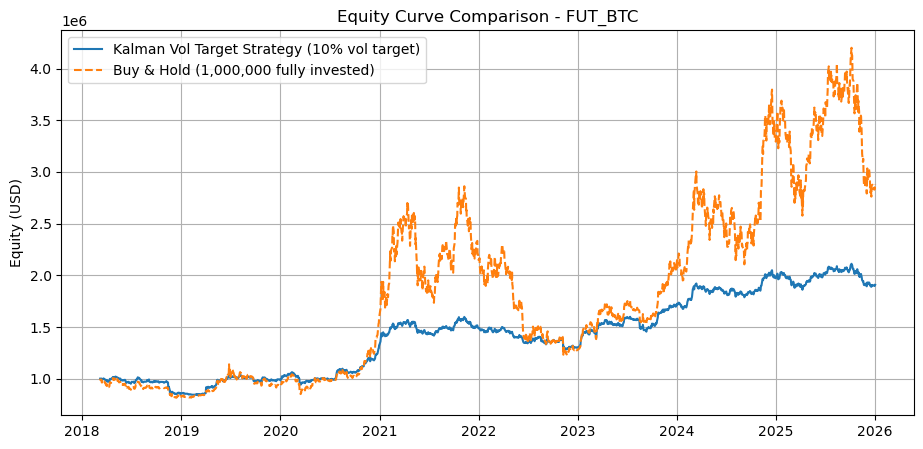


===== FUT_E6 =====
Strategy Sharpe: -0.365 | MaxDD: -49.549%
Buy&Hold Sharpe: -0.232 | MaxDD: -42.309%
Turnover total: 1511 | avg: 0.337 | ratio: 0.072


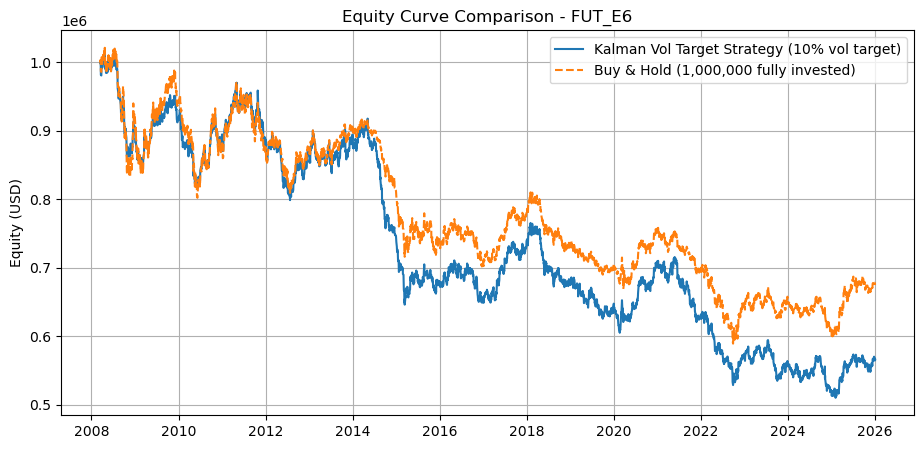


===== FUT_ES =====
Strategy Sharpe: 0.645 | MaxDD: -17.915%
Buy&Hold Sharpe: 0.593 | MaxDD: -42.489%
Turnover total: 2577 | avg: 0.574 | ratio: 0.061


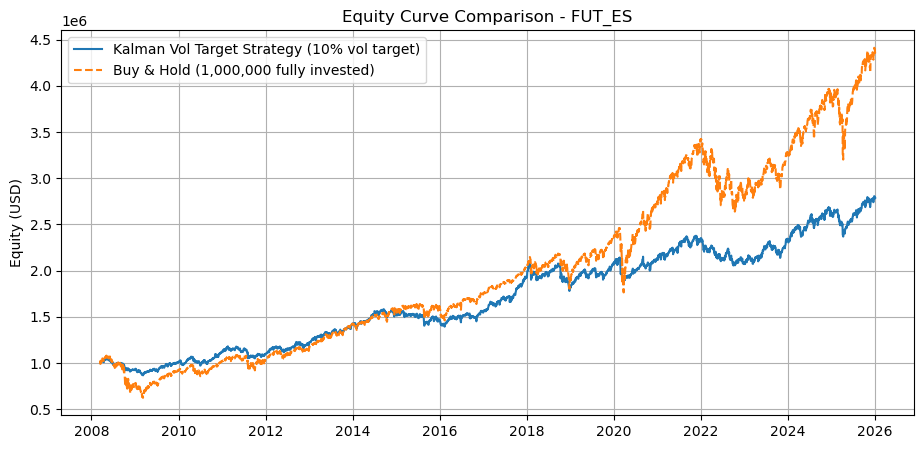


===== FUT_FDAX =====
Strategy Sharpe: 0.443 | MaxDD: -19.121%
Buy&Hold Sharpe: 0.422 | MaxDD: -40.746%
Turnover total: 931 | avg: 0.206 | ratio: 0.075


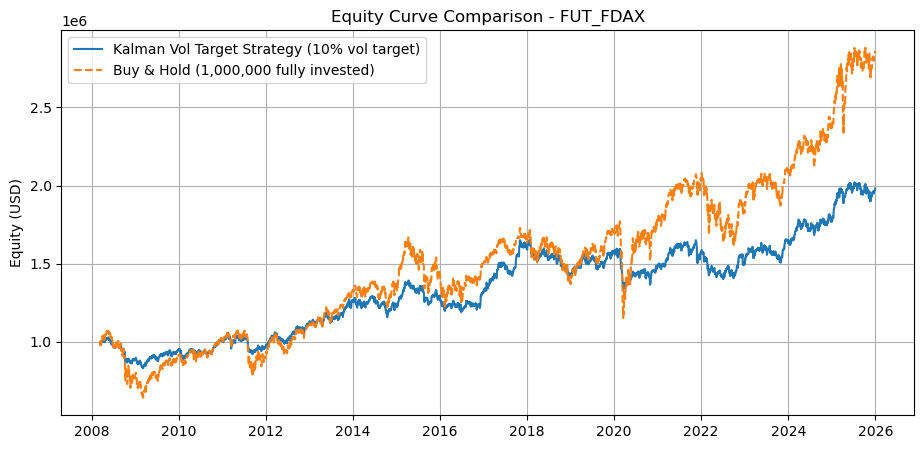


===== FUT_FGBL =====
Strategy Sharpe: 0.450 | MaxDD: -29.834%
Buy&Hold Sharpe: 0.492 | MaxDD: -26.837%
Turnover total: 3704 | avg: 0.825 | ratio: 0.048


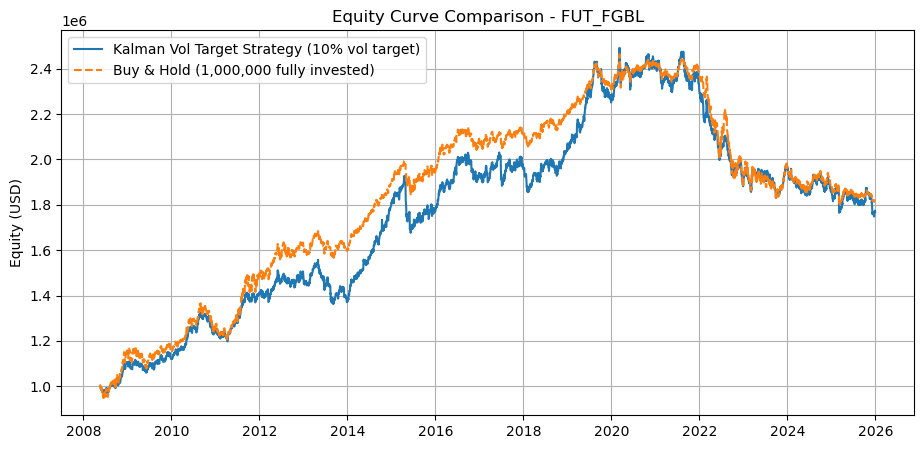


===== FUT_GC =====
Strategy Sharpe: 0.541 | MaxDD: -29.855%
Buy&Hold Sharpe: 0.496 | MaxDD: -36.132%
Turnover total: 1764 | avg: 0.395 | ratio: 0.072


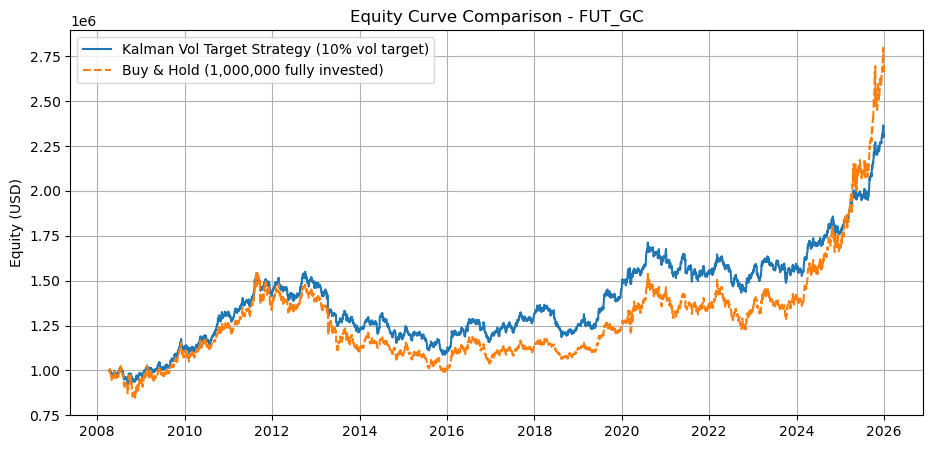


===== FUT_J7 =====
Strategy Sharpe: -0.448 | MaxDD: -62.834%
Buy&Hold Sharpe: -0.367 | MaxDD: -57.827%
Turnover total: 2037 | avg: 0.454 | ratio: 0.068


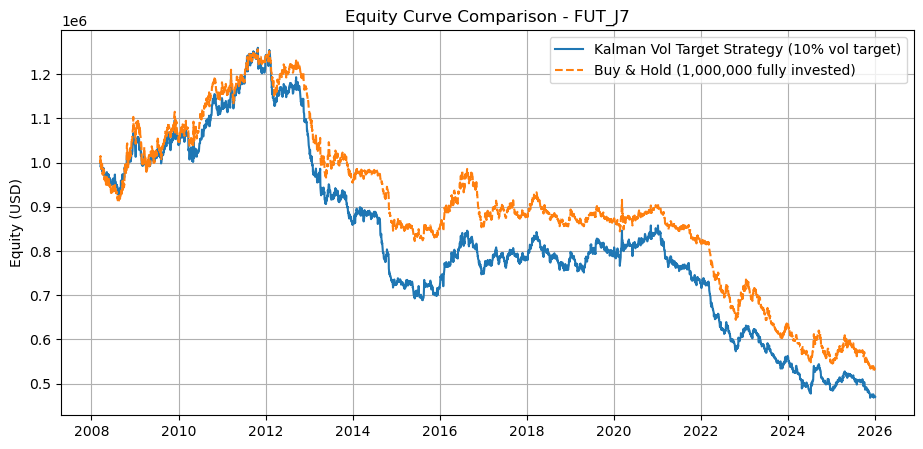


===== FUT_VX =====
Strategy Sharpe: -0.293 | MaxDD: -64.555%
Buy&Hold Sharpe: -0.308 | MaxDD: -93.546%
Turnover total: 1306 | avg: 0.300 | ratio: 0.064


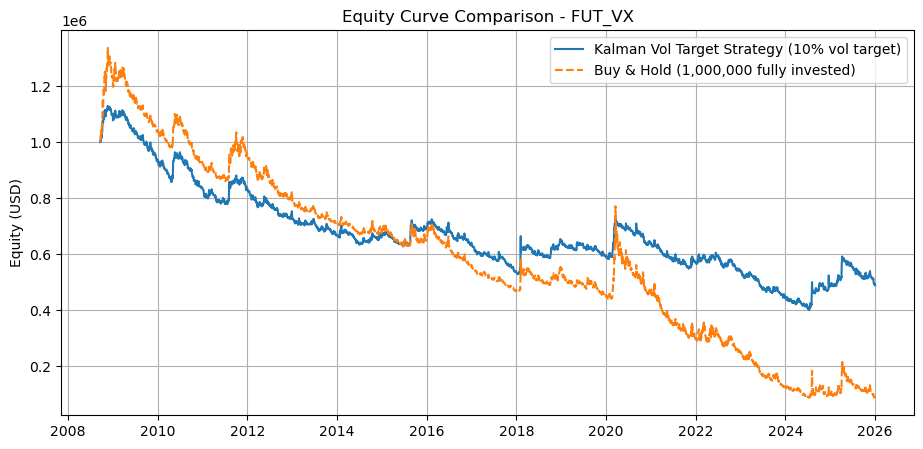


===== FUT_ZF =====
Strategy Sharpe: 0.097 | MaxDD: -29.611%
Buy&Hold Sharpe: 0.260 | MaxDD: -17.468%
Turnover total: 4240 | avg: 0.944 | ratio: 0.042


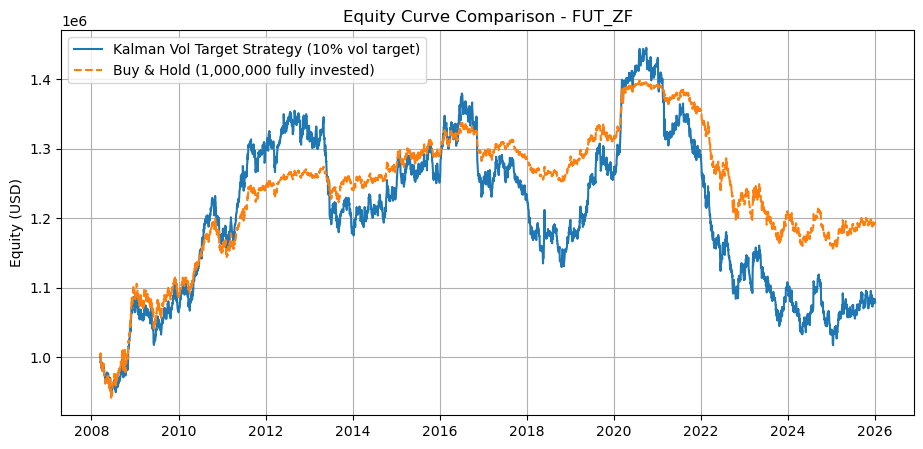


===== STK_JPM =====
Strategy Sharpe: -0.100 | MaxDD: -23.247%
Buy&Hold Sharpe: 0.024 | MaxDD: -17.471%
Turnover total: 4775303 | avg: 1680.261 | ratio: 0.039


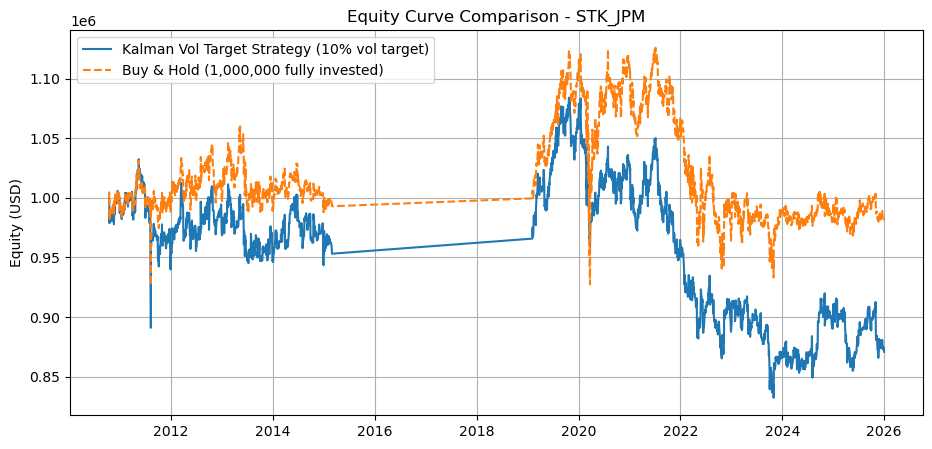


===== STK_LLY =====
Strategy Sharpe: 0.623 | MaxDD: -38.886%
Buy&Hold Sharpe: 0.621 | MaxDD: -70.270%
Turnover total: 3026780 | avg: 466.520 | ratio: 0.047


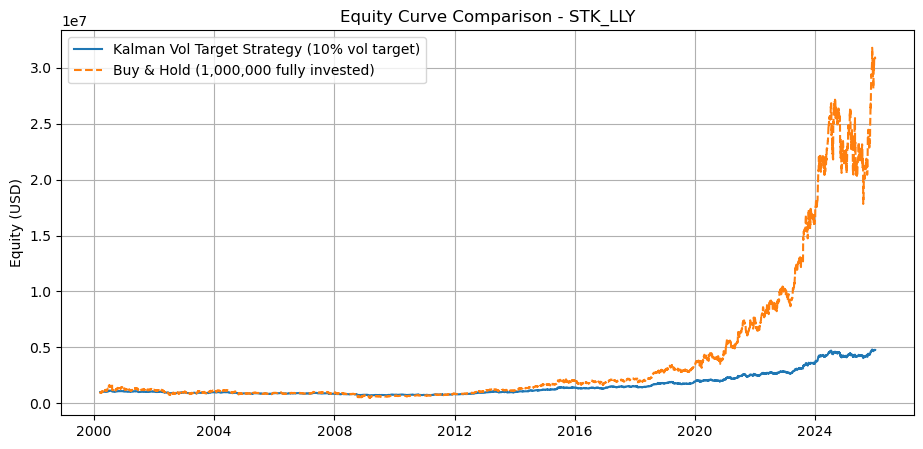


===== STK_NVDA =====
Strategy Sharpe: 0.922 | MaxDD: -27.927%
Buy&Hold Sharpe: 0.755 | MaxDD: -89.724%
Turnover total: 243089317 | avg: 37467.527 | ratio: 0.048


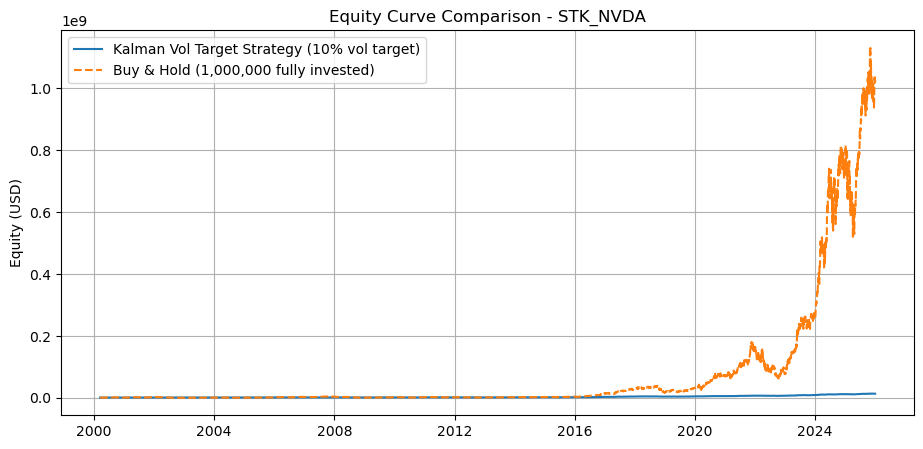


===== STK_TSLA =====
Strategy Sharpe: 0.886 | MaxDD: -23.519%
Buy&Hold Sharpe: 0.947 | MaxDD: -73.632%
Turnover total: 8412445 | avg: 2184.483 | ratio: 0.056


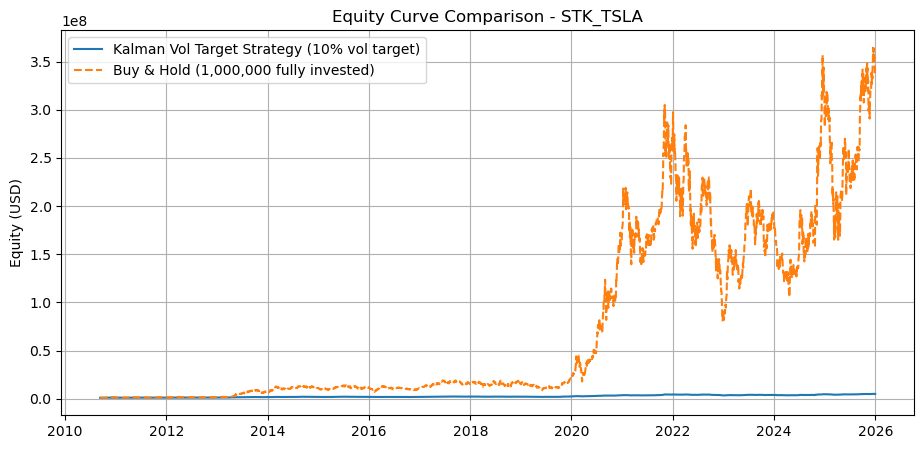


===== STK_XOM =====
Strategy Sharpe: 0.311 | MaxDD: -37.521%
Buy&Hold Sharpe: 0.406 | MaxDD: -62.396%
Turnover total: 4801322 | avg: 740.031 | ratio: 0.046


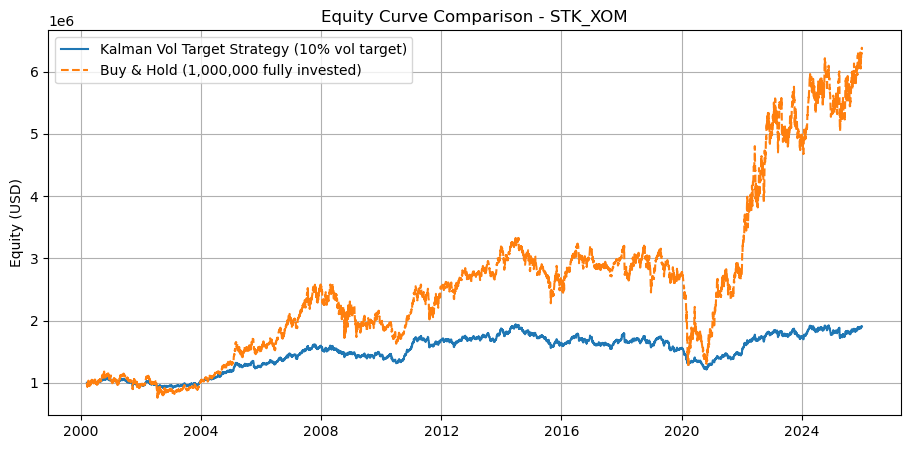

In [51]:

# FUNDAMENTAL PLOTS and METRICS - KALMAN

def max_drawdown(equity: pd.Series) -> float:
    e = equity.astype(float).dropna()
    if e.empty:
        return np.nan
    peak = e.cummax()
    dd = e / peak - 1.0
    return float(dd.min())

def sharpe(sr: pd.Series, periods_per_year: int = 252) -> float:
    r = sr.astype(float).dropna()
    if len(r) < 2:
        return np.nan
    sd = r.std(ddof=1)
    if sd == 0 or np.isnan(sd):
        return np.nan
    return float(np.sqrt(periods_per_year) * r.mean() / sd)

capital = 1_000_000

for asset in sorted(bt_kf_1d.keys()):

    bt = bt_kf_1d[asset].copy().sort_index()

    price = bt["close"].astype(float).dropna()
    strat_equity = bt["equity_usd"].astype(float).dropna()

    idx = price.index.intersection(strat_equity.index)

    price = price.loc[idx]
    strat_equity = strat_equity.loc[idx]

    bh_equity = capital * (price / price.iloc[0])

    strat_ret = strat_equity.pct_change()
    bh_ret = bh_equity.pct_change()

    strat_sh = sharpe(strat_ret)
    bh_sh = sharpe(bh_ret)

    strat_dd = max_drawdown(strat_equity)
    bh_dd = max_drawdown(bh_equity)

    trades = bt["trade"].abs()
    avg_pos = bt["contracts"].abs().mean()

    total_turnover = trades.sum()
    avg_turnover = trades.mean()

    turnover_ratio = total_turnover / (avg_pos * len(bt)) if avg_pos > 0 else np.nan

    print(f"\n===== {asset} =====")
    print(f"Strategy Sharpe: {strat_sh:.3f} | MaxDD: {strat_dd:.3%}")
    print(f"Buy&Hold Sharpe: {bh_sh:.3f} | MaxDD: {bh_dd:.3%}")
    print(f"Turnover total: {total_turnover:.0f} | avg: {avg_turnover:.3f} | ratio: {turnover_ratio:.3f}")

    plt.figure(figsize=(11,5))
    plt.plot(strat_equity, label="Kalman Vol Target Strategy (10% vol target)")
    plt.plot(bh_equity, label="Buy & Hold (1,000,000 fully invested)", linestyle="--")
    plt.title(f"Equity Curve Comparison - {asset}")
    plt.ylabel("Equity (USD)")
    plt.grid(True)
    plt.legend()
    plt.show()

## Interpreting the results

The analysis leads to a clear conclusion: the Kalman model does not improve the results obtained with EWMA. Both drawdowns and Sharpe ratios remain broadly similar. The most noticeable difference is the sharp increase in turnover. The number of contracts required to maintain the target volatility is significantly higher compared to the EWMA model. This would imply very high transaction costs in practice.

The following chart compares the behavior of the two models over time:

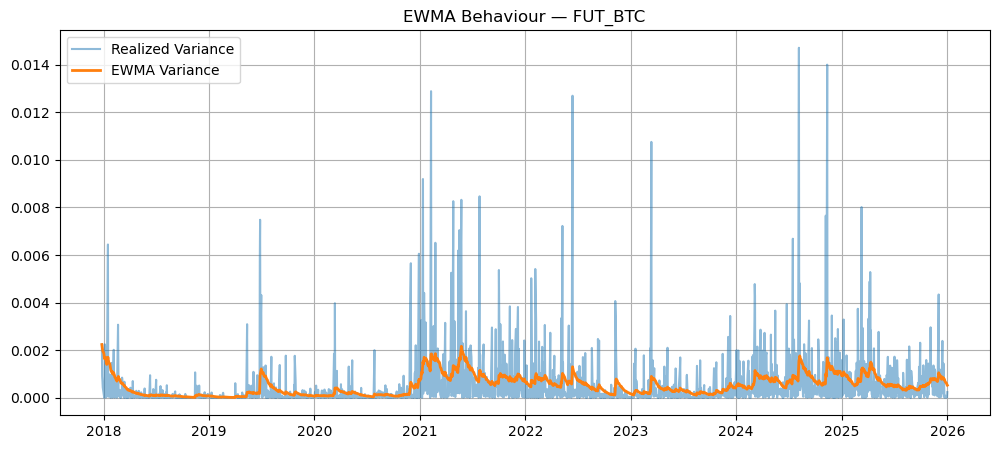

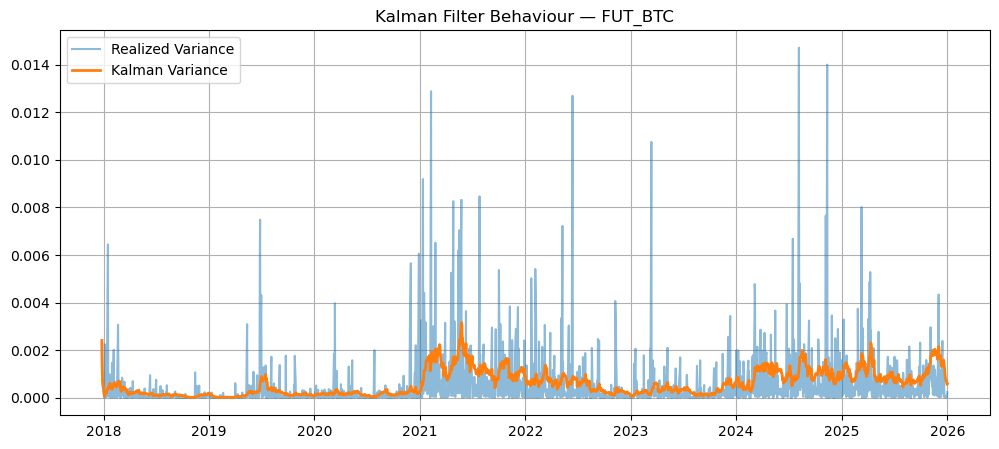

In [48]:

asset = list(df_instruments_1d.keys())[0]
df = df_instruments_1d[asset].copy()

rv = df["rv"].dropna()
rv = rv[rv > 0].copy()   

if "ewma_var" not in df.columns:
    lam = 0.94
    ewma = []
    var = rv.iloc[0]

    for r in rv:
        var = lam * var + (1 - lam) * r
        ewma.append(var)

    df.loc[rv.index, "ewma_var"] = ewma

plot_df_ewma = pd.concat(
    [
        rv.rename("RV"),
        df.loc[rv.index, "ewma_var"]
    ],
    axis=1
).dropna()

plt.figure(figsize=(12, 5))
plt.plot(plot_df_ewma.index, plot_df_ewma["RV"], label="Realized Variance", alpha=0.5)
plt.plot(plot_df_ewma.index, plot_df_ewma["ewma_var"], label="EWMA Variance", linewidth=2)
plt.title(f"EWMA Behaviour — {asset}")
plt.legend()
plt.grid(True)
plt.show()

cfg = KalmanRVConfig(
    mu=0.0,
    phi_s=0.50,
    phi_l=0.985,
    q_s=0.00001,
    q_l=0.0001,
    r=0.015
)

kf = KalmanRV2Factor(cfg)

filtered = kf.filter_series(rv)
filtered["rv_pred"] = np.exp(filtered["latent_log_vol"])

plot_df_kf = pd.concat(
    [
        rv.rename("RV"),
        filtered["rv_pred"]
    ],
    axis=1
).dropna()

plt.figure(figsize=(12, 5))
plt.plot(plot_df_kf.index, plot_df_kf["RV"], label="Realized Variance", alpha=0.5)
plt.plot(plot_df_kf.index, plot_df_kf["rv_pred"], label="Kalman Variance", linewidth=2)
plt.title(f"Kalman Filter Behaviour — {asset}")
plt.legend()
plt.grid(True)
plt.show()




It is immediately clear that the Kalman filter produces a less smooth behavior. The signal changes much more quickly. This may be due to several reasons:

1. The model does not estimate its parameters but keeps them fixed. Allowing for parameter estimation would likely lead to a more stable and controlled output.
2. The Kalman filter is inherently more prone to overfitting than EWMA, which makes it more fragile. This is particularly problematic for a volatility targeting strategy, where robustness is essential.


## Possible improvements for the Kalman model

Can improvements be made? Most likely yes. One possible approach would be to estimate the parameters of the Kalman filter, for example using maximum likelihood (MLE). Howewer I preferred to run several manual trials and set the parameters manually. The pattern I noticed by changing the parameters suggested that the models behaviour was substantially the same. I could likely have found a parameter combination yielding better results, but that would have increased the risk of overfitting and reduced the robustness of the strategy. This reduce the statistical rigor, but MLE for being implemented requires separate research, fitting and coding skills. 
Simplifying the observation and state dynamics could also help, although in this research the model was intentionally designed to use at least two latent states. 
In addition, the rigidity imposed by the diagonality of the Q and F matrices may not have been optimal.
Denoising returns is another option, but I used daily data so the microstructure noise is almost irrelevant. So in this case the smoothing has taken place just in the volatility case. 

Update: 
As a robustness check, I also tested parameter estimation and an aggregated realized variance measure built from higher-frequency returns. Although these extensions make the framework statistically more refined, they did not lead to more robust practical results in this setting. In particular, they tended to increase sensitivity and the risk of overfitting, without improving the usefulness of the model for volatility targeting. In detail, in some instrumets the accuracy was better, but in other it exploded. 

## Kalman Filter vs EWMA: Better Precision, Wrong Use Case

However, the model is not necessarily worse overall, it is simply worse for this specific purpose.

As observed earlier, the model shows higher accuracy, especially on less predictable instruments such as VIX and BTC. In these cases, the Kalman filter produced surprisingly good results in terms of QLIKE. There is clearly a higher level of fitting involved, but the improvement in these types of assets could more than compensate for it.

The filter reacts very quickly to changes, and this is exactly what sets it apart from EWMA. This same feature makes it more accurate, but also less effective as a risk management tool in a volatility targeting framework. This could have been affected by the RV proxy used for the model, maybe an aggregate model could be better. 

There are several areas where this model could be used more effectively:

- Separating short-term and long-term volatility regimes: this is already embedded in the structure of the model.
- Identifying regime changes: its responsiveness can be useful if applied to a regime filtering framework.
- Building signals for volatility of volatility: it can leverage its higher sensitivity compared to EWMA without relying directly on option pricing models.

In this sense, the Kalman filter should not be viewed as a replacement for EWMA, but as a complementary tool designed for a different layer of the decision process.
### Conclusions

Beyond the results, I was interested in showing the decisional process behind the research, highlighting the fact that one should not fall in love with a model or an idea. In this case, using Kalman instead of EWMA, after seeing QLIKEs results would have been a big mistake, fortunately I choose to rely more on turnover than on a theoretical precision. Given the reasons I mentioned, my choice is to share this version of the research, aware of its flaws. 
